In [1]:
import os

# --- ！！！必须放在第一行！！！ ---
# 允许 OpenMP 库的多个副本共存。这是解决 Torch 和 Scipy 冲突的万能药。
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import random
import torch
import numpy as np
def setup_seed(seed: int = 42, deterministic: bool = False):
    """
    统一设置 PyTorch/NumPy/Random 的随机种子
    @param seed: 基础随机种子（建议 0-2^32-1 之间）
    @param deterministic: 是否开启严格确定性模式（可能影响 GPU 性能）
    """
    # Python 内置随机数
    random.seed(seed)
    
    # NumPy 随机性
    np.random.seed(seed)
    
    # PyTorch CPU 随机性
    torch.manual_seed(seed)
    
    # PyTorch GPU 随机性（单卡+多卡）
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # 多卡情况
    
    # 确定性优化（需谨慎！可能降低 GPU 速度）
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.enabled = False  # 如需使用 cudnn，建议仅设置 deterministic=True
        
setup_seed(seed=42)

Simulating 1000 paths, evaluating at 401 time points each...
Simulating path 100/1000
Simulating path 200/1000
Simulating path 300/1000
Simulating path 400/1000
Simulating path 500/1000
Simulating path 600/1000
Simulating path 700/1000
Simulating path 800/1000
Simulating path 900/1000
Simulating path 1000/1000
Simulation complete. 1000/1000 paths successfully integrated.
1000 valid paths will be used for analysis.


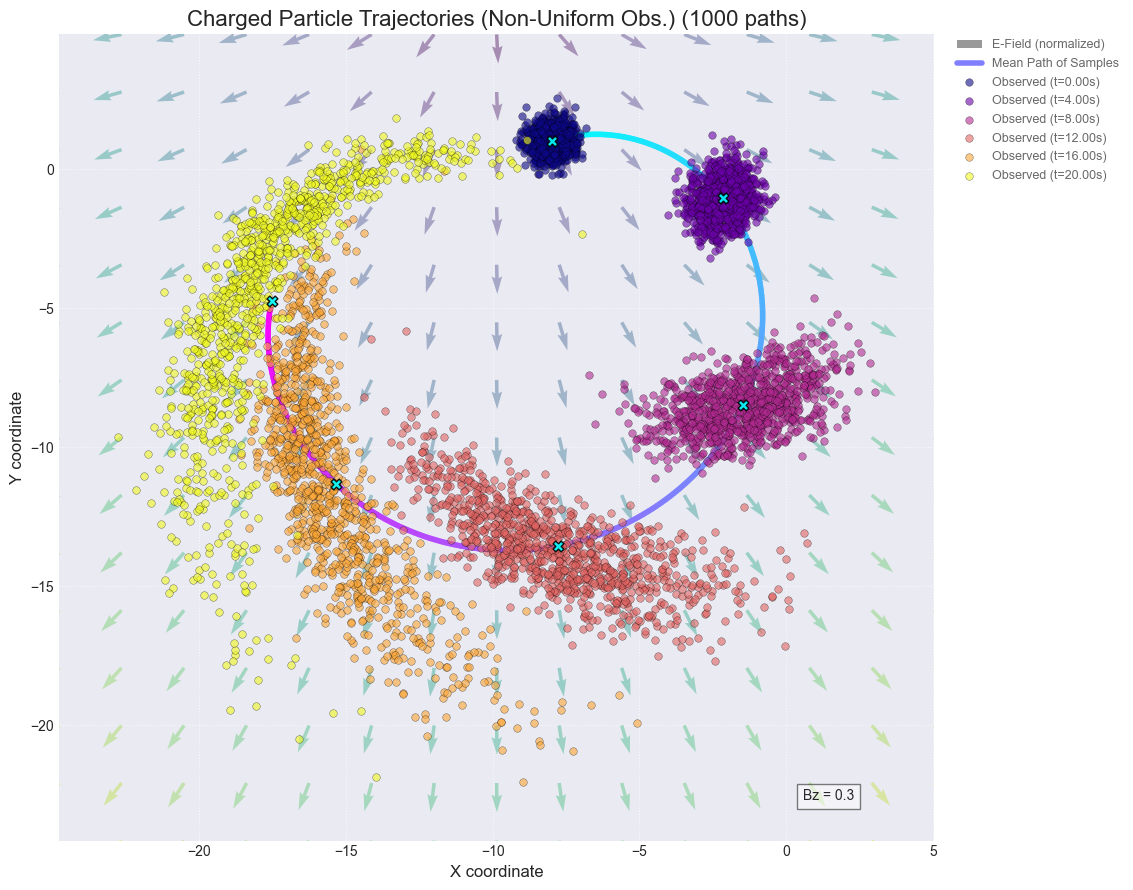


--- Generated PyTorch Tensors ---
Trajectories Tensor Shape: torch.Size([1000, 6, 2])
Conditions Tensor Shape:   torch.Size([1000, 3])

An example condition vector (q/m, x0, y0, vx0, vy0):
tensor([1.0497, 1.3092, 0.4140])


In [3]:
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import os
from datetime import datetime

# --- Simulation Parameters ---
num_paths = 1000
total_simulation_time = 20.0  # Total time to simulate

# Define your custom, potentially non-uniform observation times here:
USER_SPECIFIED_OBSERVATION_TIMES = list(np.arange(0, 20.1, 4.0)) # 4s 间隔


current_time_str = datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename_prefix = f"lorentz_force_paths_{current_time_str}"

# --- Field Configuration ---
# Electric field E(x,y) = (Ex_func(x,y), Ey_func(x,y))
Ex_coeffs = {'const': 0.1, 'x': 0.01, 'y': 0.0}
Ey_coeffs = {'const': -0.05, 'x': 0.0, 'y': 0.005}

def Ex_field(x, y, coeffs=Ex_coeffs):
    return coeffs['const'] + coeffs['x'] * x + coeffs['y'] * y

def Ey_field(x, y, coeffs=Ey_coeffs):
    return coeffs['const'] + coeffs['x'] * x + coeffs['y'] * y

# Magnetic field B = (0, 0, Bz) - uniform and perpendicular to XY plane
Bz_uniform = 0.3

# --- Particle Mean Properties and Standard Deviations ---
q_m_mean = 1.0          # Mean charge-to-mass ratio
q_m_std = 0.1          # Std dev for q/m

r0_mean = np.array([-8.0, 1.0]) # Mean initial position [x, y]
r0_std = 0.4                  # Std dev for initial position

v0_mean = np.array([1.5, 0.5])  # Mean initial velocity [vx, vy]
v0_std = 0.1                  # Std dev for initial velocity

# --- Process Observation Times ---
# Ensure 0 and total_simulation_time are included, sort, and keep unique
custom_observation_times = np.sort(np.unique(
    np.clip(np.concatenate(([0], USER_SPECIFIED_OBSERVATION_TIMES, [total_simulation_time])), 0, total_simulation_time)
))
NUM_OBSERVED_TIMEPOINTS = len(custom_observation_times)

# --- Time points for ODE solver ---
# Fine time points for smooth plotting of mean trajectory
num_fine_plot_steps = int(total_simulation_time * 20) + 1 # Approx 25 steps per time unit for smoothness
t_eval_fine_plotting = np.linspace(0, total_simulation_time, num_fine_plot_steps)

# Combine fine plotting points with custom observation points for the solver
t_eval_for_solver = np.sort(np.unique(np.concatenate((t_eval_fine_plotting, custom_observation_times))))
num_solver_eval_points = len(t_eval_for_solver)


# --- ODE function for a single particle ---
def charged_particle_ode(t, y_state, q_m_ratio, Ex_fn, Ey_fn, Bz_val):
    x, y, vx, vy = y_state
    Ex = Ex_fn(x, y)
    Ey = Ey_fn(x, y)
    ax = q_m_ratio * (Ex + vy * Bz_val)
    ay = q_m_ratio * (Ey - vx * Bz_val)
    return [vx, vy, ax, ay]

# --- Generate Initial Conditions for Each Path ---
paths_q_m_ratios = np.random.normal(q_m_mean, q_m_std, num_paths)
paths_q_m_ratios = np.maximum(paths_q_m_ratios, 0.1 * np.sign(q_m_mean) if q_m_mean != 0 else 0.1)
paths_r0 = r0_mean + np.random.randn(num_paths, 2) * r0_std
paths_v0 = v0_mean + np.random.randn(num_paths, 2) * v0_std

# --- Simulate Paths ---
all_paths_solver_eval_list = [] # Stores full solution at t_eval_for_solver points
all_paths_conditions_list = [] # MODIFICATION: List to store condition vectors

print(f"Simulating {num_paths} paths, evaluating at {num_solver_eval_points} time points each...")
successful_simulations = 0
for i in range(num_paths):
    if (i+1) % 100 == 0:
        print(f"Simulating path {i+1}/{num_paths}")
    
    y0 = np.concatenate((paths_r0[i], paths_v0[i]))
    q_m = paths_q_m_ratios[i]

    # MODIFICATION: Create the condition vector for this path: [q/m, vx0, vy0]
    condition_vector = np.concatenate(([q_m], paths_v0[i]))
    
    sol = solve_ivp(
        charged_particle_ode,
        [0, total_simulation_time],
        y0,
        args=(q_m, Ex_field, Ey_field, Bz_uniform),
        dense_output=False,
        t_eval=t_eval_for_solver,
        method='RK45',
        rtol=1e-6, atol=1e-8
    )
    
    if sol.success and sol.y.shape[1] == num_solver_eval_points:
        all_paths_solver_eval_list.append(sol.y[:2, :].T)
        all_paths_conditions_list.append(condition_vector) # MODIFICATION: Store condition vector on success
        successful_simulations += 1
    else:
        print(f"Warning: Path {i} ODE solve failed. Status: {sol.status if hasattr(sol, 'status') else 'N/A'}")
        nan_path = np.full((num_solver_eval_points, 2), np.nan)
        all_paths_solver_eval_list.append(nan_path)
        nan_condition = np.full(condition_vector.shape, np.nan) # MODIFICATION: Store NaN placeholder for conditions
        all_paths_conditions_list.append(nan_condition)

all_paths_solver_eval = np.array(all_paths_solver_eval_list)
all_paths_conditions = np.array(all_paths_conditions_list) # MODIFICATION: Convert conditions list to numpy array
print(f"Simulation complete. {successful_simulations}/{num_paths} paths successfully integrated.")

if successful_simulations == 0:
    print("Error: No paths were successfully simulated. Exiting.")
    exit()

# MODIFICATION: Filter both trajectories and conditions using the same mask
valid_paths_mask = ~np.all(np.isnan(all_paths_solver_eval), axis=(1,2))
all_paths_solver_eval_filtered = all_paths_solver_eval[valid_paths_mask]
all_paths_conditions_filtered = all_paths_conditions[valid_paths_mask]

if all_paths_solver_eval_filtered.shape[0] == 0:
    print("Error: No valid paths after filtering. Exiting.")
    exit()
    
num_valid_paths = all_paths_solver_eval_filtered.shape[0]
print(f"{num_valid_paths} valid paths will be used for analysis.")

# --- Extract Observed Data at Custom Times ---
observation_point_indices_in_solver_eval = np.where(np.isin(t_eval_for_solver, custom_observation_times))[0]
observed_paths_data = all_paths_solver_eval_filtered[:, observation_point_indices_in_solver_eval, :]


# --- Calculate Mean Path for Visualization ---
mean_path_for_plotting = np.nanmean(all_paths_solver_eval_filtered, axis=0)

# --- Visualization ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(14, 9))

# Plot E-field
plot_margin = 2.0
all_pos_data_flat = all_paths_solver_eval_filtered.reshape(-1, 2)
valid_pos_data = all_pos_data_flat[~np.isnan(all_pos_data_flat).any(axis=1)]

if valid_pos_data.shape[0] > 0:
    x_min_data, y_min_data = np.min(valid_pos_data, axis=0)
    x_max_data, y_max_data = np.max(valid_pos_data, axis=0)
else:
    x_min_data, y_min_data = r0_mean - plot_margin
    x_max_data, y_max_data = r0_mean + plot_margin
    
x_min_plot = min(x_min_data, r0_mean[0]) - plot_margin
x_max_plot = max(x_max_data, r0_mean[0]) + plot_margin
y_min_plot = min(y_min_data, r0_mean[1]) - plot_margin
y_max_plot = max(y_max_data, r0_mean[1]) + plot_margin


grid_x, grid_y = np.meshgrid(np.linspace(x_min_plot, x_max_plot, 15),
                                 np.linspace(y_min_plot, y_max_plot, 15))
E_field_x_plot = Ex_field(grid_x, grid_y)
E_field_y_plot = Ey_field(grid_x, grid_y)
E_magnitude = np.sqrt(E_field_x_plot**2 + E_field_y_plot**2)
E_field_x_norm = E_field_x_plot / (E_magnitude + 1e-9)
E_field_y_norm = E_field_y_plot / (E_magnitude + 1e-9)

ax.quiver(grid_x, grid_y, E_field_x_norm, E_field_y_norm, E_magnitude, cmap='viridis', alpha=0.4, scale=30, width=0.004, label='E-Field (normalized)')
ax.text(x_max_plot - (x_max_plot-x_min_plot)*0.15 , y_min_plot + (y_max_plot-y_min_plot)*0.05, f"Bz = {Bz_uniform}", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

# Plot the mean path
num_segments_mean_plot = len(mean_path_for_plotting) - 1
cmap_mean_path = plt.cm.cool
for k_segment in range(num_segments_mean_plot):
    p1 = mean_path_for_plotting[k_segment]
    p2 = mean_path_for_plotting[k_segment+1]
    if not (np.isnan(p1).any() or np.isnan(p2).any()):
        segment_color = cmap_mean_path(t_eval_for_solver[k_segment] / total_simulation_time)
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                 color=segment_color, linestyle='-', linewidth=4.0, alpha=0.9, zorder=2)
ax.plot([], [], color=cmap_mean_path(0.5), linestyle='-', linewidth=4.0, label='Mean Path of Samples')

# Plot scatter of individual paths AT CUSTOM OBSERVED TIMEPOINTS
cmap_scatter = plt.cm.plasma
for k_obs in range(NUM_OBSERVED_TIMEPOINTS):
    time_at_obs = custom_observation_times[k_obs]
    points_at_observed_t = observed_paths_data[:, k_obs, :]
    
    valid_scatter_points = points_at_observed_t[~np.isnan(points_at_observed_t).any(axis=1)]

    if valid_scatter_points.shape[0] > 0:
        scatter_plot_color = cmap_scatter(time_at_obs / total_simulation_time)
        ax.scatter(valid_scatter_points[:, 0], valid_scatter_points[:, 1],
                   color=scatter_plot_color, 
                   s=30, alpha=0.6, edgecolor='black', linewidth=0.3,
                   label=f'Observed (t={time_at_obs:.2f}s)',
                   zorder=3)
    
    # Mark the mean path's position AT THIS CUSTOM OBSERVATION TIME
    idx_on_mean_path = np.where(t_eval_for_solver == time_at_obs)[0]
    if idx_on_mean_path.size > 0:
        mean_pos_at_obs_time = mean_path_for_plotting[idx_on_mean_path[0]]
        if not np.isnan(mean_pos_at_obs_time).any():
            ax.scatter(mean_pos_at_obs_time[0], mean_pos_at_obs_time[1],
                       color='cyan', marker='X', s=60, zorder=4, alpha=0.9, edgecolor='black')

ax.set_title(f'Charged Particle Trajectories (Non-Uniform Obs.) ({num_valid_paths} paths)', fontsize=16)
ax.set_xlabel('X coordinate', fontsize=12)
ax.set_ylabel('Y coordinate', fontsize=12)
legend = ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0., fontsize=9)
plt.setp(legend.get_texts(), color='dimgray')
ax.set_xlim(x_min_plot, x_max_plot)
ax.set_ylim(y_min_plot, y_max_plot)
ax.grid(True, linestyle=':', alpha=0.7)
fig.tight_layout(rect=[0, 0, 0.82, 1])
plt.savefig('Particle_sample.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- Save as PyTorch Tensors ---
if observed_paths_data.shape[0] > 0:
    # Trajectory Tensor (the original output)
    trajectories_tensor = torch.tensor(observed_paths_data, dtype=torch.float32)
    
    # MODIFICATION: Create the corresponding conditions tensor
    conditions_tensor = torch.tensor(all_paths_conditions_filtered, dtype=torch.float32)

    print("\n--- Generated PyTorch Tensors ---")
    print(f"Trajectories Tensor Shape: {trajectories_tensor.shape}")
    print(f"Conditions Tensor Shape:   {conditions_tensor.shape}")
    print("\nAn example condition vector (q/m, x0, y0, vx0, vy0):")
    print(conditions_tensor[0])

    # MODIFICATION: Save both tensors together in a dictionary for easy loading
    data_to_save = {
        'trajectories': trajectories_tensor,
        'conditions': conditions_tensor,
        'observation_times': torch.tensor(custom_observation_times, dtype=torch.float32)
    }


    train_data = {
        'trajectories': trajectories_tensor[:int(trajectories_tensor.shape[0]*0.7)],
        'conditions': conditions_tensor[:int(trajectories_tensor.shape[0]*0.7)],
        'observation_times': torch.tensor(custom_observation_times, dtype=torch.float32)
    }
    val_data = {
        'trajectories': torch.tensor(all_paths_solver_eval_filtered)[int(trajectories_tensor.shape[0]*0.7):],
        'conditions': conditions_tensor[int(trajectories_tensor.shape[0]*0.7):],
        'observation_times': torch.tensor(custom_observation_times, dtype=torch.float32)
    }


    # output_dir = f"simulated_data_{current_time_str}"
    # os.makedirs(output_dir, exist_ok=True)
    # save_path = os.path.join(output_dir, f"{output_filename_prefix}_conditional_data.pt")
    # torch.save(data_to_save, save_path)
    # print(f"\nSimulated trajectories and conditions saved to {save_path}")
else:
    print("No valid data to save after filtering.")
    
    
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection # 新增导入
# --- Animation Function (Modified) ---
def animate_particle_paths(all_paths_data, mean_path_data, time_points, observation_times,
                           Ex_fn, Ey_fn, Bz_val, x_lims, y_lims, grid_x_efield, grid_y_efield,
                           total_sim_time_param): # Added total_sim_time_param
    """
    Generates and displays an animation of particle paths with time-varying colors.
    """
    fig_anim, ax_anim = plt.subplots(figsize=(14, 14))
    num_anim_paths = all_paths_data.shape[0]
    num_all_time_steps = all_paths_data.shape[1] # Total time steps available from solver

    cmap_paths = plt.cm.cool # Colormap for individual and mean paths
    cmap_current_markers = plt.cm.plasma # Colormap for current position markers

    # Determine animation frames
    target_anim_duration_sec = 15
    target_fps = 20 # Increased for smoother color transitions
    num_anim_frames = target_anim_duration_sec * target_fps
    
    if num_all_time_steps <= num_anim_frames:
        anim_frame_indices = np.arange(num_all_time_steps)
    else:
        anim_frame_indices = np.linspace(0, num_all_time_steps - 1, num_anim_frames, dtype=int)
        anim_frame_indices = np.unique(anim_frame_indices)
    
    actual_num_anim_frames = len(anim_frame_indices)

    # Plot E-field (static background)
    E_field_x_anim = Ex_fn(grid_x_efield, grid_y_efield)
    E_field_y_anim = Ey_fn(grid_x_efield, grid_y_efield)
    E_magnitude_anim = np.sqrt(E_field_x_anim**2 + E_field_y_anim**2)
    E_field_x_norm_anim = E_field_x_anim / (E_magnitude_anim + 1e-9)
    E_field_y_norm_anim = E_field_y_anim / (E_magnitude_anim + 1e-9)
    ax_anim.quiver(grid_x_efield, grid_y_efield, E_field_x_norm_anim, E_field_y_norm_anim, E_magnitude_anim,
                   cmap='viridis', alpha=0.3, scale=30, width=0.0035)
    ax_anim.text(x_lims[1] - (x_lims[1]-x_lims[0])*0.15 , y_lims[0] + (y_lims[1]-y_lims[0])*0.05,
                 f"Bz = {Bz_val}", fontsize=9, bbox=dict(facecolor='white', alpha=0.5))

    # Initialize LineCollections for each path
    path_linecollections = []
    for i in range(num_anim_paths):
        lc = LineCollection([],  cmap=cmap_paths, norm=plt.Normalize(0, 1), lw=0.8, alpha=0.6)
        ax_anim.add_collection(lc)
        path_linecollections.append(lc)

    # Initialize LineCollection for mean path
    mean_path_lc = LineCollection([], cmap=cmap_paths, norm=plt.Normalize(0, 1), lw=2.5, alpha=0.9)
    ax_anim.add_collection(mean_path_lc)
    # Dummy plot for legend entry for mean path
    ax_anim.plot([],[], color=cmap_paths(0.5), lw=2.5, label='Mean Path (Live)')


    # Initialize scatter for current positions of particles
    current_pos_scatter = ax_anim.scatter([], [], s=50, alpha=0.8, zorder=3, edgecolor='black', linewidth=0.2)
    # Dummy plot for legend entry for current positions (color will change)
    ax_anim.scatter([],[], s=50, color=cmap_current_markers(0.5), label='Current Positions', edgecolor='black', linewidth=0.2)


    # Initialize scatter for observed points on mean path (color is fixed per point once set)
    observed_mean_markers = ax_anim.scatter([], [], s=100, marker='X', c=[], cmap=cmap_current_markers, # Use plasma for these too
                                             norm=plt.Normalize(0,1), edgecolor='black', alpha=0.9, zorder=4,
                                             label='Observed Times (Mean)')
    
    time_text = ax_anim.text(0.02, 0.95, '', transform=ax_anim.transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

    ax_anim.set_xlim(x_lims)
    ax_anim.set_ylim(y_lims)
    ax_anim.set_title(f'Animated Particle Trajectories ({num_anim_paths} paths)', fontsize=15)
    ax_anim.set_xlabel('X coordinate', fontsize=11)
    ax_anim.set_ylabel('Y coordinate', fontsize=11)
    ax_anim.grid(True, linestyle=':', alpha=0.6)
    ax_anim.legend(loc='upper right', fontsize=8)
    fig_anim.tight_layout()

    plotted_observation_indices_mean_abs = [] # Store absolute solver indices of plotted obs times for mean path

    def update(frame_k):
        # frame_k is an index into anim_frame_indices
        # solver_idx is the actual index into the full data arrays (all_paths_data, time_points)
        solver_idx = anim_frame_indices[frame_k]
        current_time = time_points[solver_idx]
        
        # Update individual path LineCollections
        for i, lc in enumerate(path_linecollections):
            path_data_so_far = all_paths_data[i, :solver_idx+1, :]
            valid_mask = ~np.isnan(path_data_so_far).any(axis=1)
            path_data_valid = path_data_so_far[valid_mask]

            if path_data_valid.shape[0] > 1:
                points = path_data_valid.reshape(-1, 1, 2)
                segments = np.concatenate([points[:-1], points[1:]], axis=1)
                lc.set_segments(segments)
                # Color segments by the normalized time of the start of each segment
                segment_times = time_points[:solver_idx+1][valid_mask][:-1] # Times for start points of segments
                normalized_segment_times = segment_times / total_sim_time_param
                lc.set_array(normalized_segment_times)
            else:
                lc.set_segments([]) # Clear if not enough points

        # Update mean path LineCollection
        mean_path_data_so_far = mean_path_data[:solver_idx+1, :]
        valid_mean_mask = ~np.isnan(mean_path_data_so_far).any(axis=1)
        mean_path_valid = mean_path_data_so_far[valid_mean_mask]

        if mean_path_valid.shape[0] > 1:
            points_mean = mean_path_valid.reshape(-1, 1, 2)
            segments_mean = np.concatenate([points_mean[:-1], points_mean[1:]], axis=1)
            mean_path_lc.set_segments(segments_mean)
            segment_times_mean = time_points[:solver_idx+1][valid_mean_mask][:-1]
            normalized_segment_times_mean = segment_times_mean / total_sim_time_param
            mean_path_lc.set_array(normalized_segment_times_mean)
        else:
            mean_path_lc.set_segments([])
        
        # Update current positions scatter
        current_x = all_paths_data[:, solver_idx, 0]
        current_y = all_paths_data[:, solver_idx, 1]
        valid_current_points_mask = ~np.isnan(current_x) & ~np.isnan(current_y)
        current_pos_scatter.set_offsets(np.c_[current_x[valid_current_points_mask], current_y[valid_current_points_mask]])
        current_normalized_time = current_time / total_sim_time_param
        current_pos_scatter.set_color(cmap_current_markers(current_normalized_time))
        
        # Update observed mean markers (add new ones if observation time is passed)
        newly_added_obs_mean_points_coords = []
        newly_added_obs_mean_points_colors_normalized_time = []

        for obs_time in observation_times:
            # Find the solver index closest to this observation time
            obs_time_solver_idx = np.argmin(np.abs(time_points - obs_time))
            
            if obs_time_solver_idx <= solver_idx and obs_time_solver_idx not in plotted_observation_indices_mean_abs:
                mean_pos_at_obs = mean_path_data[obs_time_solver_idx, :]
                if not np.isnan(mean_pos_at_obs).any():
                    newly_added_obs_mean_points_coords.append(mean_pos_at_obs)
                    newly_added_obs_mean_points_colors_normalized_time.append(time_points[obs_time_solver_idx] / total_sim_time_param)
                plotted_observation_indices_mean_abs.append(obs_time_solver_idx)
        
        if newly_added_obs_mean_points_coords:
            current_offsets = observed_mean_markers.get_offsets()
            current_colors_data = observed_mean_markers.get_array() # This gets the color values
            
            all_coords = np.array(newly_added_obs_mean_points_coords)
            all_colors_data = np.array(newly_added_obs_mean_points_colors_normalized_time)

            if current_offsets.shape[0] > 0 and current_offsets.ndim == 2:
                updated_offsets = np.vstack([current_offsets, all_coords])
                updated_colors_data = np.concatenate([current_colors_data, all_colors_data])
            else:
                updated_offsets = all_coords
                updated_colors_data = all_colors_data
            
            observed_mean_markers.set_offsets(updated_offsets)
            observed_mean_markers.set_array(updated_colors_data) # Update colors based on their observation time


        time_text.set_text(f'Time: {current_time:.2f} s / {total_sim_time_param:.1f} s')
        
        artists_to_return = path_linecollections + [mean_path_lc, current_pos_scatter, observed_mean_markers, time_text]
        return artists_to_return

    anim = FuncAnimation(fig_anim, update, frames=len(anim_frame_indices), # Use actual_num_anim_frames
                         interval=max(20, 1000 // target_fps), blit=True, repeat=True) # repeat=True for looping
    plt.show()
    return anim

from IPython.display import HTML, display
# --- Call Animation Function ---
# if all_paths_solver_eval_filtered.shape[0] > 0:
#     print("\nPreparing animation with time-varying colors...")
#     animation_object = animate_particle_paths(
#         all_paths_solver_eval_filtered,
#         mean_path_for_plotting,
#         t_eval_for_solver, # These are the time points for the data
#         custom_observation_times,
#         Ex_field, Ey_field, Bz_uniform,
#         (x_min_plot, x_max_plot), (y_min_plot, y_max_plot),
#         grid_x, grid_y,
#         total_simulation_time # Pass total_simulation_time for normalization
#     )
#     display(HTML(animation_object.to_html5_video())) 
# else:
#     print("No valid data to animate.")

In [4]:
import torch
import torch.nn.functional as F
import os
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

import cubic_SI
from cubic_SI import model
from cubic_SI import computations as cmp

Successfully imported configured torchcubicspline.


In [5]:
SI_class = model.Cubic_SI_model(train_data['trajectories'], USER_SPECIFIED_OBSERVATION_TIMES,condition_tensor=train_data['conditions'],
                                n_layers=4,hiden_size=128,
                                N_training=10000, B=128, model_lr=1e-3,steps=20*total_simulation_time,
                                spline=True,
                                save_path='model_history/lorentz_force_paths_spline',record_gap=10
                                )

117122
117122


processed: 10000: 100%|██████████| 10000/10000 [04:15<00:00, 39.19it/s, loss=0.0017270007, loss_b=0.0017270007, loss_k=0.0]


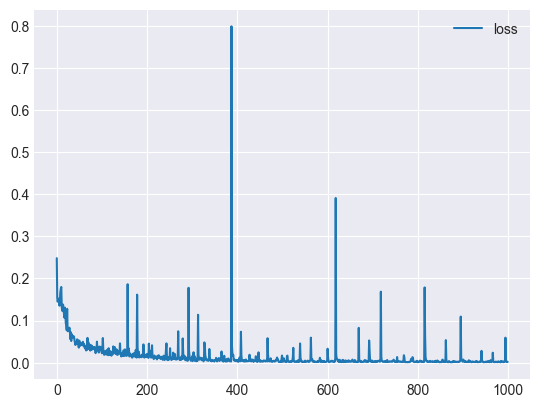

In [6]:
SI_class.train()

In [7]:
generated_paths_ODE = SI_class.eval(val_data['trajectories'][:,0,:],conditions=val_data['conditions'],SDE=False)
generated_paths_ODE = torch.stack(generated_paths_ODE).transpose(0,1)
generated_paths_ODE_spline = generated_paths_ODE

117122
117122


processed: 10000: 100%|██████████| 10000/10000 [05:30<00:00, 30.24it/s, loss=0.16129234, loss_b=0.16129234, loss_k=0.0]


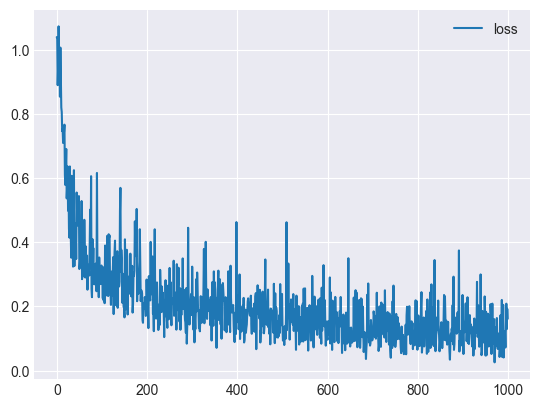

In [8]:
SI_class = model.Cubic_SI_model(train_data['trajectories'], USER_SPECIFIED_OBSERVATION_TIMES,condition_tensor=train_data['conditions'],
                                n_layers=4,hiden_size=128,
                                N_training=10000, B=128, model_lr=1e-3,steps=20*total_simulation_time,
                                spline=False,
                                save_path='model_history/lorentz_force_paths_linear',record_gap=10
                                )
SI_class.train()
generated_paths_ODE = SI_class.eval(val_data['trajectories'][:,0,:],conditions=val_data['conditions'],SDE=False)
generated_paths_ODE = torch.stack(generated_paths_ODE).transpose(0,1)
generated_paths_ODE_linear = generated_paths_ODE

In [9]:
val_data = {
    'trajectories': torch.tensor(all_paths_solver_eval_filtered)[int(trajectories_tensor.shape[0]*0.7):],
    'conditions': conditions_tensor[int(trajectories_tensor.shape[0]*0.7):],
    'observation_times': torch.tensor(custom_observation_times, dtype=torch.float32)
}

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7136\2891718726.py:1321: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(train_data['observation_times']), torch.tensor(t_eval_for_solver), EXPERIMENT_CONFIG


Using device: cuda

--- Creating *placeholder* output files for your models... ---

--- Generating [Synthetic ODE] Data ---
Creating data bundle...
   Training samples: 700
   Validation samples: 300
   Sparse times (S): 6
   Dense times (T_gen): 401
   Validation truth times (T_val): 401

        Phase 1: Starting *Baseline* Model Training        

--- Processing Model: GaussianProcess ---
       Optimizing GaussianProcess hyperparameters (10000 steps, lr=0.1)...


       GaussianProcess hyperparameter optimization complete.
      Training complete. Time elapsed: 1053.16s
      (GaussianProcess is non-parametric)

--- Processing Model: LatentODEVaE ---
      Model: LatentODEVaE, Trainable Parameters: 134,018


  Epoch 10000/10000 | ELBO: 0.0259 (R: 0.0060, KL: 1.9937): 100%|██████████| 10000/10000 [1:36:58<00:00,  1.72it/s]



      Training complete. Time elapsed: 5818.23s

--- Processing Model: ConditionalTransformer ---
      Model: ConditionalTransformer, Trainable Parameters: 137,858


...

       Processing model: LatentODEVaE
      Calculating time-step metrics (using Sinkhorn)...


       Processing model: ConditionalTransformer
      Calculating time-step metrics (using Sinkhorn)...


       Processing model: CSI
      Calculating time-step metrics (using Sinkhorn)...


       Processing model: SSCI
      Calculating time-step metrics (using Sinkhorn)...



--- 正在生成 MSE 指标图 ---
   [Plot] Mean Squared Error (MSE): 在 'LatentODEVaE' (max=2.31e+00) 和 'GaussianProcess' (max=1.90e+01) 之间检测到首个显著差距 (Ratio: 8.2)。


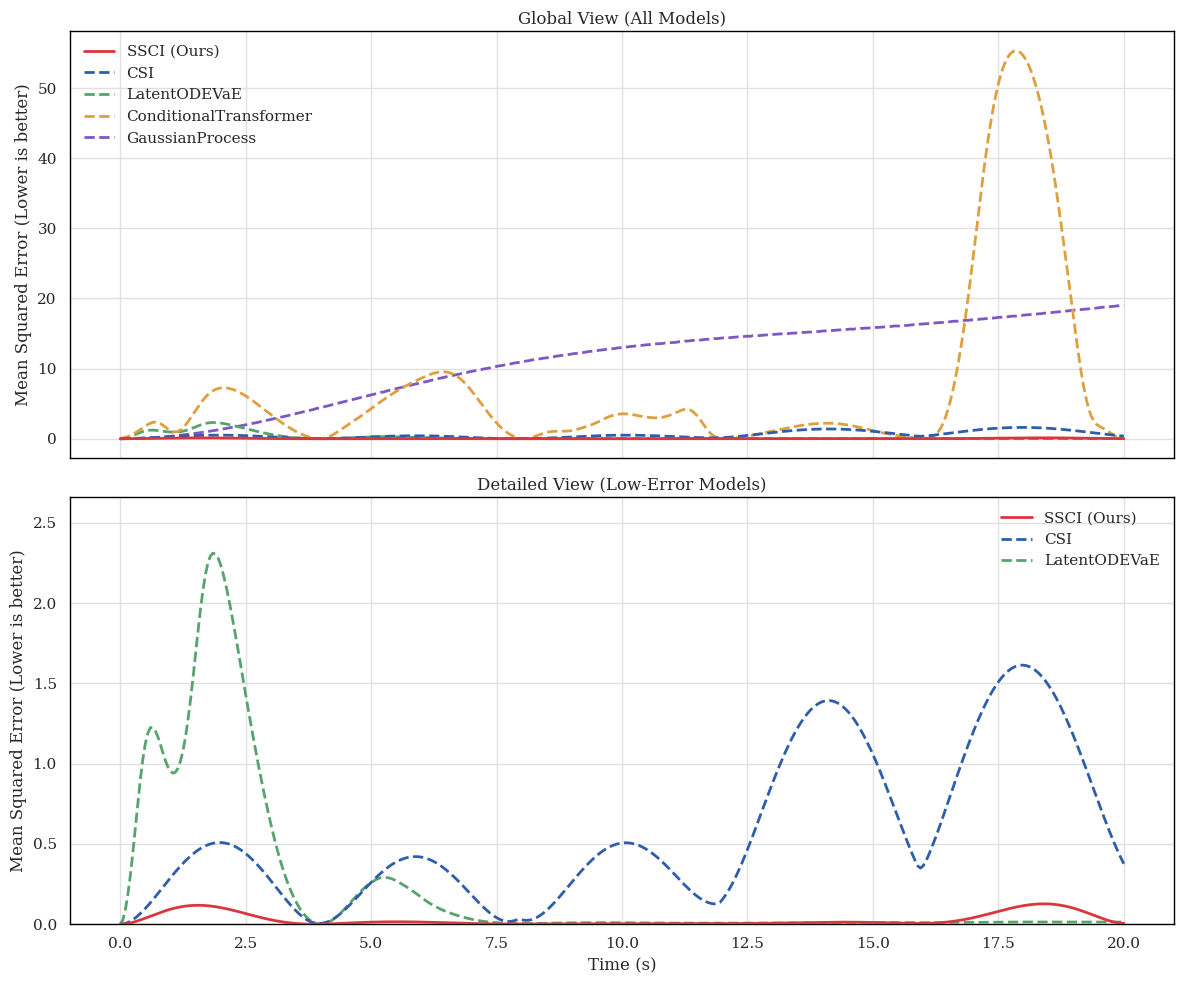


--- 正在生成 Wasserstein 指标图 ---
   [Plot] Wasserstein Distance: 在 'LatentODEVaE' (max=2.21e+00) 和 'GaussianProcess' (max=6.88e+00) 之间检测到首个显著差距 (Ratio: 3.1)。


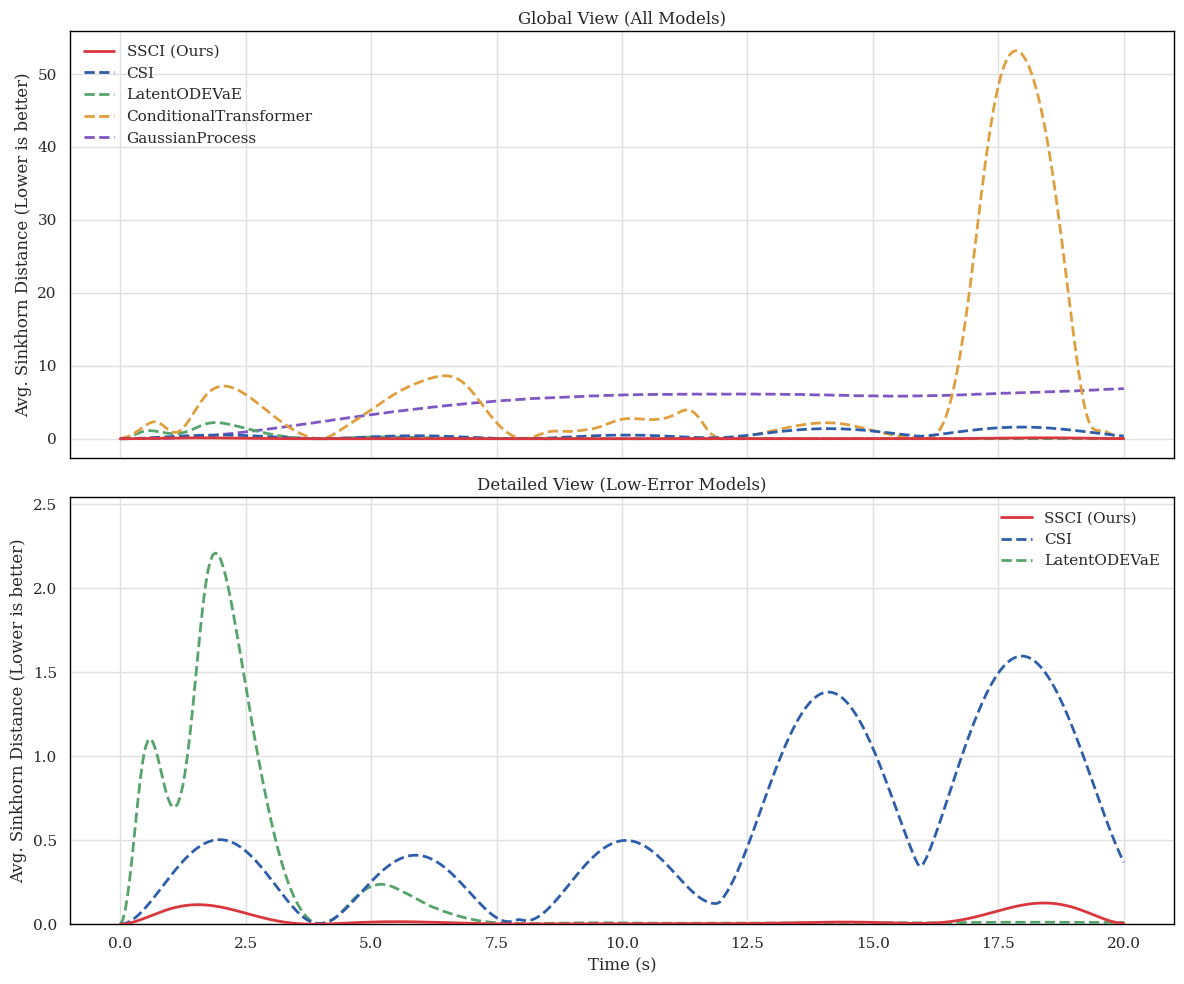


   --- Starting Sparse-on-Sparse Evaluation ---
       (Truth is dense; sub-sampling to sparse)
       Processing model: GaussianProcess
      Calculating time-step metrics (using Sinkhorn)...


       Processing model: LatentODEVaE
      Calculating time-step metrics (using Sinkhorn)...


       Processing model: ConditionalTransformer
      Calculating time-step metrics (using Sinkhorn)...


       Processing model: CSI
      Calculating time-step metrics (using Sinkhorn)...


       Processing model: SSCI
      Calculating time-step metrics (using Sinkhorn)...



--- 正在生成 MSE 指标图 ---
   [Plot] Mean Squared Error (MSE): 在 'LatentODEVaE' (max=1.40e-02) 和 'ConditionalTransformer' (max=1.44e-01) 之间检测到首个显著差距 (Ratio: 10.3)。


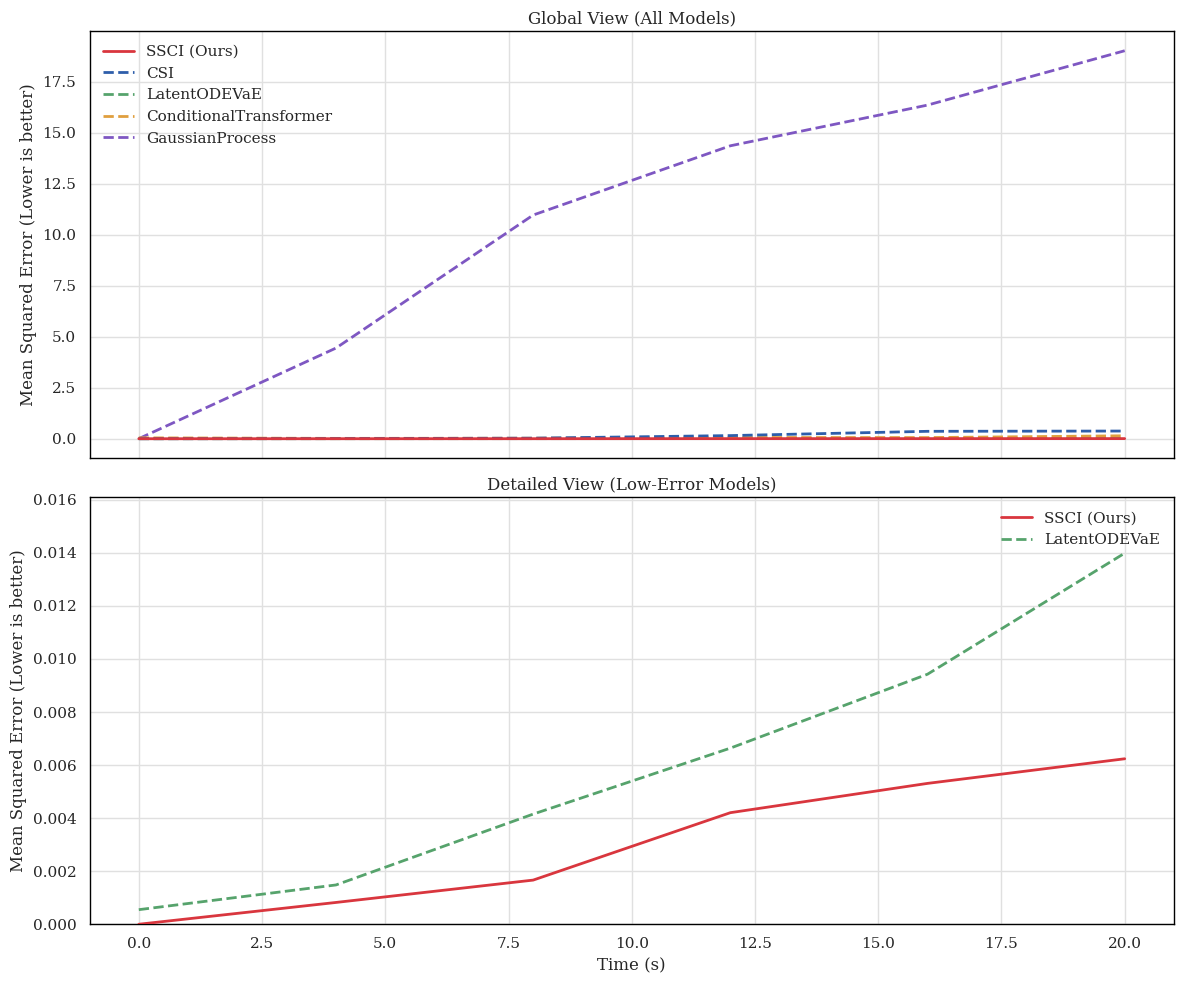


--- 正在生成 Wasserstein 指标图 ---
   [Plot] Wasserstein Distance: 在 'LatentODEVaE' (max=1.10e-02) 和 'ConditionalTransformer' (max=1.15e-01) 之间检测到首个显著差距 (Ratio: 10.4)。


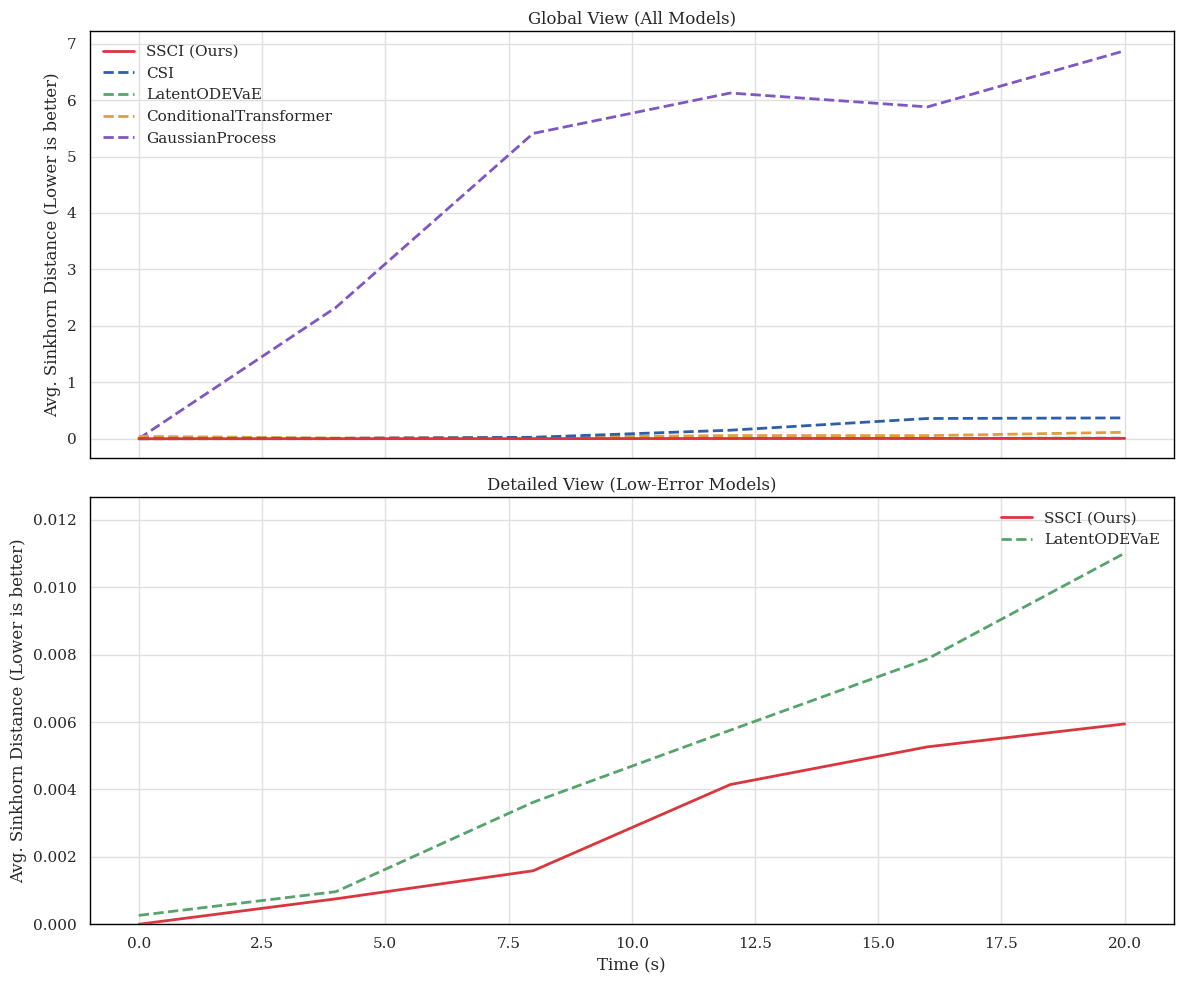


   --- Starting Path Visualization (2D/3D) ---
Generating Clean Trajectory Visualizations for ODE...
Saved static figure to Trajectory_Samples_ODE.pdf


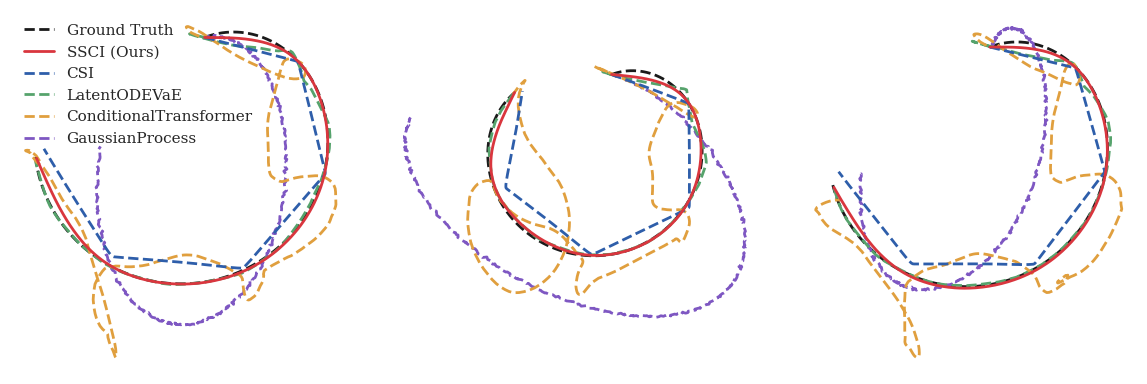

Generating Clean Animation for Sample 0...
Saved animation to ODE_Sample0_Animation.mp4


In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from geomloss import SamplesLoss # Make sure to pip install geomloss
import numpy as np
import time
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm # <-- 确保 tqdm 已导入
import os
from pathlib import Path
import matplotlib.patches as mpatches
import torch.nn.functional as F # <-- 确保 F 已导入
import warnings # <-- (添加)
from linear_operator.utils.warnings import NumericalWarning # <-- (添加)
import gc # <-- (添加)

# ==============================================================================
# 0. Dependencies Check
# ==============================================================================
try: 
    from torchdiffeq import odeint
except ImportError:
    raise ImportError("Please install torchdiffeq: pip install torchdiffeq")
try:
    import torchsde
except ImportError:
    raise ImportError("Please install torchsde: pip install torchsde")
try:
    import gpytorch
    from gpytorch.likelihoods import GaussianLikelihood
    from gpytorch.means import ConstantMean
    from gpytorch.kernels import ScaleKernel, RBFKernel
    from gpytorch.distributions import MultivariateNormal
except ImportError:
    raise ImportError("Please install gpytorch: pip install gpytorch")

# ==============================================================================
# 1. Experiment, Data, and Model Configuration
# ==============================================================================

# Experiment Config: Defines problem dimensions and execution device
# (假设 train_data 已经在此处定义)
EXPERIMENT_CONFIG = {
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
    "DATA_DIM": train_data['trajectories'].shape[-1],
    "COND_DIM": train_data['conditions'].shape[-1],
    "BATCH_SIZE": 128,
}


# Model Config: (*** 已修改 ***) 
# 替换为 "Fair" 版本的 L-ODE/L-SDE
# 添加了 vae_hidden_dim 和 dyn_hidden_dim
MODEL_CONFIG = {
    # "ConditionalGRU": {
    #     "hidden_dim": 64, "epochs": 20, "lr": 1e-3
    # },
    
    # --- MODIFIED: 使用 "Fair" 版本 ---
    "LatentODEVaE": {
        "latent_dim": 128,         # 潜空间维度
        "vae_hidden_dim": 128,     # VAE 编码器/解码器的隐藏维度
        "dyn_hidden_dim": 128,     # (1P) 动力学网络(f)的隐藏维度
        "kl_weight": 0.01,
        "epochs": 10000, 
        "lr": 1e-3
    },
    
    "LatentSDEVaE": {
        "latent_dim": 128,         # 潜空间维度
        "vae_hidden_dim": 128,     # VAE 编码器/解码器的隐藏维度
        "dyn_hidden_dim": 128,     # (1P) 动力学网络(f)的隐藏维度
        "diffusion_hyperparam": 0.1, # SDE 的 g(t,z) 超参数
        "kl_weight": 0.01,
        "epochs": 10000,
        "lr": 1e-3
    },
    # --- 结束修改 ---

    "ConditionalTransformer": {
        "embed_dim": 32,
        "nhead": 4, 
        "num_layers": 1, 
        "epochs": 10000, 
        "lr": 1e-3
    },
    "ConditionalGP": {
        "optim_steps": 10000, 
        "lr": 1e-1
    },
}


STYLE_CONFIG = {
    # --- 核心方法 (Our Method) ---
    "SSCI": {
        "color": "#D9363E",  # [Pyro] 绯红 (Klee Red) - 醒目但不刺眼
        "lw": 2.0,           # 线条最粗
        "linestyle": "-",    # 实线
        "zorder": 100,       # 永远在最顶层 (防止被遮挡)
        "alpha": 1.0,        # 不透明
        "label": "SSCI (Ours)"
    },
    
    # --- 主要对比方法 (Strong Baseline) ---
    "CSI": {
        "color": "#2E5EAA",  # [Hydro] 深宝石蓝 (Eula Blue) - 沉稳
        "lw": 2.0,           # 线条次粗
        "linestyle": "--",    # 实线
        "zorder": 90,        # 仅次于 SSCI
        "alpha": 1.0,
        "label": "CSI"
    },

    # --- 神经网络基线 (Neural Baselines) ---
    "LatentODEVaE": {       # 注意：匹配您代码中的键名(含空格)
        "color": "#56A36C",  # [Dendro] 草神绿 (Nahida Green) - 清新
        "lw": 2.0,           # 标准线宽
        "linestyle": "--",   # 虚线 (区分于 Ours)
        "zorder": 10,        # 后景
        "alpha": 1.0,
        "label": "LatentODEVaE"
    },
    
    # "LatentSDEVaE": {
    #     "color": "#7E57C2",  # [Electro] 雷电紫 (Raiden Purple) - 优雅
    #     "lw": 1.5,
    #     "linestyle": "--",
    #     "zorder": 10,
    #     "alpha": 1.0,
    #     "label": "LatentSDEVaE"
    # },
    
    "ConditionalTransformer": {
        "color": "#E09F3E",  # [Geo] 岩金 (Zhongli Amber) - 明亮
        "lw": 2.0,
        "linestyle": "--",   # 点划线 (增加区分度)
        "zorder": 10,
        "alpha": 1.0,
        "label": "ConditionalTransformer"
    },

    # --- 传统/非参基线 (Traditional/Non-Parametric) ---
    "GaussianProcess": {
        "color": "#7E57C2",  # [Electro] 雷电紫 (Raiden Purple) - 优雅 "#26A69A",  # [Anemo] 魈青 (Xiao Teal) - 高级灰调
        "lw": 2.0,
        "linestyle": "--",    # 点线 (表示非参的不确定性或不同性质)
        "zorder": 5,         # 最底层
        "alpha": 1.0,
        "label": "GaussianProcess"
    }
}

# ==============================================================================
# 2. Baseline Model Definitions
# ==============================================================================

# --- Model 1: Conditional GRU (Unchanged) ---
class ConditionalGRU(nn.Module):
    def __init__(self, data_dim, cond_dim, hidden_dim=64, **kwargs):
        super().__init__()
        self.data_dim, self.hidden_dim = data_dim, hidden_dim
        self.gru_cell = nn.GRUCell(data_dim + cond_dim + 1, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, data_dim)
    def forward(self, sparse_data, sparse_times, condition):
        batch_size, seq_len, _ = sparse_data.shape
        h = torch.zeros(batch_size, self.hidden_dim, device=sparse_data.device, dtype=sparse_data.dtype)
        outputs = []
        for i in range(seq_len):
            x_t = sparse_data[:, i, :]
            t_curr = sparse_times[:, i].unsqueeze(-1)
            t_prev = sparse_times[:, i-1].unsqueeze(-1) if i > 0 else torch.zeros_like(t_curr)
            delta_t = t_curr - t_prev
            inp = torch.cat([x_t, condition, delta_t], dim=1)
            h = self.gru_cell(inp, h)
            outputs.append(self.fc_out(h))
        return torch.stack(outputs, dim=1)
    def generate(self, x0, t_eval, condition):
        batch_size = x0.shape[0]
        h = torch.zeros(batch_size, self.hidden_dim, device=x0.device, dtype=x0.dtype)
        x_t = x0
        path = [x0]
        for i in range(1, len(t_eval)):
            delta_t = (t_eval[i] - t_eval[i-1]).view(1, 1).repeat(batch_size, 1).to(x0.device, dtype=x0.dtype)
            inp = torch.cat([x_t, condition, delta_t], dim=1)
            h = self.gru_cell(inp, h)
            x_t = self.fc_out(h)
            path.append(x_t)
        return torch.stack(path, dim=1)

# --- Model 2: Conditional Transformer (Unchanged) ---
class ConditionalTransformer(nn.Module):
    def __init__(self, data_dim, cond_dim, embed_dim=64, nhead=4, num_layers=2, **kwargs):
        super().__init__()
        self.time_encoder = nn.Linear(1, embed_dim)
        self.input_proj = nn.Linear(data_dim, embed_dim)
        self.cond_proj = nn.Linear(cond_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(embed_dim, data_dim)
    def forward(self, sparse_data, sparse_times, condition):
        seq_len = sparse_times.shape[1] 
        x0 = sparse_data[:, 0, :].unsqueeze(1).repeat(1, seq_len, 1) 
        time_embed = torch.sin(self.time_encoder(sparse_times.unsqueeze(-1).to(x0.dtype))) 
        data_embed = self.input_proj(x0) 
        cond_embed = self.cond_proj(condition).unsqueeze(1) 
        full_embedding = data_embed + time_embed + cond_embed
        output = self.transformer_encoder(full_embedding)
        return self.output_proj(output)
    def generate(self, x0, t_eval, condition):
        batch_size = x0.shape[0]
        seq_len = len(t_eval) 
        dummy_data = x0.unsqueeze(1).repeat(1, seq_len, 1)
        t_eval_batch = t_eval.unsqueeze(0).repeat(batch_size, 1).to(x0.device, dtype=x0.dtype) 
        return self.forward(dummy_data, t_eval_batch, condition)

# --- Model 3: Conditional Gaussian Process (MODIFIED) ---
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, cond_dim):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = ConstantMean()
        self.covar_module = ScaleKernel(RBFKernel(ard_num_dims=1 + cond_dim))
    def forward(self, x):
        mean_x = self.mean_module(x); covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

class ConditionalGP:
    def __init__(self, data_dim, cond_dim, device, optim_steps=50, lr=0.1, **kwargs):
        self.data_dim, self.cond_dim, self.device = data_dim, cond_dim, device
        self.models, self.likelihoods = [None] * data_dim, [None] * data_dim
        self.optim_steps = optim_steps; self.lr = lr

    def to_device(self, device):
        """将所有内部模型和似然移动到指定设备"""
        self.device = device
        for i in range(self.data_dim):
            if self.models[i]:
                self.models[i] = self.models[i].to(device)
            if self.likelihoods[i]:
                self.likelihoods[i] = self.likelihoods[i].to(device)
        return self

    def to_cpu(self):
        """将所有内部模型和似然移动到 CPU"""
        return self.to_device('cpu')

    def train(self, sparse_obs, sparse_times, conditions):
        # (train 方法保持不变, 仍然使用警告捕获)
        print(f"       Optimizing GaussianProcess hyperparameters ({self.optim_steps} steps, lr={self.lr})...")
        num_samples = conditions.shape[0]; num_sparse_obs = sparse_obs.shape[1]
        train_x = sparse_times.float().unsqueeze(0).repeat(num_samples, 1).view(-1, 1).to(self.device)
        train_c = conditions.float().unsqueeze(1).repeat(1, num_sparse_obs, 1).view(-1, self.cond_dim).to(self.device)
        train_x_cond = torch.cat([train_x, train_c], dim=-1).to(self.device)
        
        if self.data_dim > 10:
             print(f"       [Warning] GP data_dim is {self.data_dim}. Training will be very slow.")
        
        with warnings.catch_warnings():
            warnings.filterwarnings(
                'ignore', 
                message="CG terminated in", 
                category=NumericalWarning, 
                module="linear_operator.utils.linear_cg"
            )
            
            with gpytorch.settings.max_cg_iterations(2000):
                
                dim_pbar = tqdm(range(self.data_dim), desc="     GP Dimensions", leave=False)
                
                for i in dim_pbar:
                    train_y = sparse_obs[:, :, i].reshape(-1).to(self.device)
                    likelihood = GaussianLikelihood().to(self.device)
                    model = ExactGPModel(train_x_cond, train_y.float(), likelihood, self.cond_dim).to(self.device) 
                    model.train(); likelihood.train()
                    optimizer = torch.optim.Adam(model.parameters(), lr=self.lr)
                    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
                    
                    final_loss = 0.0
                    for step in range(self.optim_steps): 
                        optimizer.zero_grad(); output = model(train_x_cond)
                        loss = -mll(output, train_y); loss.backward(); optimizer.step()
                        
                        if step == self.optim_steps - 1:
                            final_loss = loss.item()
                    
                    model.eval(); likelihood.eval()
                    self.models[i], self.likelihoods[i] = model, likelihood
                    
                    dim_pbar.set_description(f"     GP Dim {i+1}/{self.data_dim} (Loss: {final_loss:.2f})")
        
        print("       GaussianProcess hyperparameter optimization complete.")


    def generate(self, x0, t_eval, condition):
        """
        <<< MODIFIED: 
        已还原为完整的批次生成模式 (Batch generation)。
        这在低维数据上更快。
        """
        x0 = x0.float().to(self.device)
        t_eval = t_eval.float().to(self.device) 
        condition = condition.float().to(self.device)
        
        batch_size = x0.shape[0] # (B)
        
        t_eval_full = torch.cat([torch.tensor([0.0], device=self.device), t_eval])
        num_eval_points_total = len(t_eval_full) 
        
        paths_future_all_dims = [] 
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            
            # 1. 在数据维度上进行循环
            for i in range(self.data_dim): 
                model = self.models[i]; likelihood = self.likelihoods[i]
                
                # --- 完整的批次计算 (B > 1) ---
                # test_x_t_full shape: [B, T_gen+1, 1]
                test_x_t_full = t_eval_full.view(1, -1, 1).repeat(batch_size, 1, 1)
                
                # test_x_c_full shape: [B, T_gen+1, cond_dim]
                test_x_c_full = condition.unsqueeze(1).repeat(1, num_eval_points_total, 1)
                
                # eval_inputs shape: [B, T_gen+1, 1+cond_dim]
                eval_inputs = torch.cat([test_x_t_full, test_x_c_full], dim=-1)
                
                # <<< 内存瓶颈点 >>>
                # joint_posterior 包含 (B, T_gen+1, N_train) 的交叉协方差
                # 在低维 (N_train 较小) 时这是可行的
                joint_posterior = likelihood(model(eval_inputs))
                
                mean_joint = joint_posterior.mean
                covar_joint = joint_posterior.lazy_covariance_matrix
                
                y_0_observed = x0[:, i] # Shape (B,)
                mu_0 = mean_joint[:, 0]
                mu_future = mean_joint[:, 1:]
                
                jitter = 1e-6
                K_00_noisy = covar_joint[:, 0, 0].add(jitter)
                K_future_0 = covar_joint[:, 1:, 0]
                K_0_future = covar_joint[:, 0, 1:]
                K_future_future_noisy = covar_joint[:, 1:, 1:]

                K_00_inv = K_00_noisy.unsqueeze(-1)
                y_0_diff = (y_0_observed - mu_0).unsqueeze(-1)
                
                K_term = K_future_0 / K_00_inv
                mean_cond = mu_future + K_term * y_0_diff
                covar_cond = K_future_future_noisy - K_term.unsqueeze(2) * K_0_future.unsqueeze(1) 
                
                diag_jitter = torch.diag_embed(torch.full_like(mean_cond, 1e-6))
                cond_posterior = MultivariateNormal(mean_cond, covar_cond + diag_jitter)
                
                # paths_dim_i_future shape (B, T_gen)
                paths_dim_i_future = cond_posterior.sample()
                paths_future_all_dims.append(paths_dim_i_future)
            
        # 2. 组合所有维度
        # final_paths shape (B, T_gen, data_dim)
        final_paths = torch.stack(paths_future_all_dims, dim=2)
        return final_paths

# --- (MODIFIED) Model 4: Latent ODE VAE [Fair, __init__ 已修正, return 已检查] ---
class LatentODEVaE(nn.Module):
    """
    基线 1 (1P-Dyn): L-ODE VAE
    Encoder -> net_f -> Decoder
    """
    
    # 动力学网络 (net_f)
    class _LatentODEFunc(nn.Module):
        def __init__(self, latent_dim, cond_dim, dyn_hidden_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(latent_dim + 1 + cond_dim, dyn_hidden_dim), nn.Tanh(),
                nn.Linear(dyn_hidden_dim, dyn_hidden_dim), nn.Tanh(),
                nn.Linear(dyn_hidden_dim, latent_dim)
            )
        def forward(self, t, z, c):
            t_batch = t.expand(z.shape[0], 1).to(z.dtype)
            inp = torch.cat([z, t_batch, c], dim=1)
            return self.net(inp) # <<< 确保 'return' 存在
    
    class _ODEFuncWrapper(nn.Module):
        def __init__(self, ode_func_net):
            super().__init__(); self.ode_func_net = ode_func_net; self.condition = None
        def set_condition(self, condition): self.condition = condition
        def forward(self, t, z):
            if self.condition is None: raise ValueError("Condition not set.")
            return self.ode_func_net(t, z, self.condition) # <<< 确保 'return' 存在

    # L-ODE VAE 主类
    # <<< __init__ 签名现在匹配 MODEL_CONFIG (vae_hidden_dim, dyn_hidden_dim) >>>
    def __init__(self, data_dim, cond_dim, latent_dim, vae_hidden_dim, dyn_hidden_dim, **kwargs):
        super().__init__()
        # --- (A) VAE 编码器 ---
        self.encoder_mlp = nn.Sequential(
            nn.Linear(data_dim, vae_hidden_dim), nn.ReLU(),
            nn.Linear(vae_hidden_dim, vae_hidden_dim)
        )
        self.z0_head = nn.Linear(vae_hidden_dim + cond_dim, latent_dim * 2) 
        
        # --- (B) 动力学网络 (net_f) ---
        self.ode_func = self._LatentODEFunc(latent_dim, cond_dim, dyn_hidden_dim)
        self.ode_wrapper = self._ODEFuncWrapper(self.ode_func)
        
        # --- (C) VAE 解码器 ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, vae_hidden_dim), nn.ReLU(),
            nn.Linear(vae_hidden_dim, vae_hidden_dim), nn.ReLU(),
            nn.Linear(vae_hidden_dim, data_dim)
        )
        self.z0_prior = torch.distributions.Normal(torch.tensor(0.0), torch.tensor(1.0))

    def forward(self, sparse_data, sparse_times, condition, **kwargs): # (添加 **kwargs)
        if sparse_data.shape[1] < 1: raise ValueError("序列长度小于 1")
        x0 = sparse_data[:, 0, :]; final_h = self.encoder_mlp(x0); combined_h_cond = torch.cat([final_h, condition], dim=1)
        z0_params = self.z0_head(combined_h_cond); mu_z0, log_sigma_z0 = z0_params.chunk(2, dim=1)
        q_z0 = torch.distributions.Normal(mu_z0, F.softplus(log_sigma_z0)); z0_sample = q_z0.rsample()
        self.ode_wrapper.set_condition(condition); times_to_solve = sparse_times[0]
        
        # (您的 traceback 显示您有 rtol/atol, 所以我在这里保留它们)
        z_t_pred = odeint(self.ode_wrapper, z0_sample, times_to_solve, method='dopri5', rtol=1e-3, atol=1e-3)
        
        z_t_pred = z_t_pred.permute(1, 0, 2); x_pred = self.decoder(z_t_pred)
        return x_pred, q_z0 # <<< 确保 'return' 存在
    
    def generate(self, x0, t_eval, condition):
        final_h = self.encoder_mlp(x0); combined_h_cond = torch.cat([final_h, condition], dim=1) 
        z0_params = self.z0_head(combined_h_cond); mu_z0, log_sigma_z0 = z0_params.chunk(2, dim=1)
        q_z0_given_x0_c = torch.distributions.Normal(mu_z0, F.softplus(log_sigma_z0)); z0_sample = q_z0_given_x0_c.rsample() 
        self.ode_wrapper.set_condition(condition)
        
        # (您的 traceback 显示您有 rtol/atol, 所以我在这里保留它们)
        z_t_gen = odeint(self.ode_wrapper, z0_sample, t_eval, method='dopri5', rtol=1e-3, atol=1e-3)
        
        z_t_gen = z_t_gen.permute(1, 0, 2); x_gen = self.decoder(z_t_gen)
        return x_gen # <<< 确保 'return' 存在
    
    
# --- (MODIFIED) Model 5: Latent SDE VAE [Fair, Fixed G, Speed Fix, __init__ 已修正] ---
class LatentSDEVaE(nn.Module):
    """
    基线 2 (1P-Dyn): L-SDE VAE (g 为超参数)
    """
    class _LatentSDEFunc(nn.Module):
        noise_type = "diagonal"; sde_type = "ito"
        def __init__(self, latent_dim, cond_dim, dyn_hidden_dim, diffusion_hyperparam):
            super().__init__()
            self.drift_net = nn.Sequential(
                nn.Linear(latent_dim + 1 + cond_dim, dyn_hidden_dim), nn.Tanh(),
                nn.Linear(dyn_hidden_dim, dyn_hidden_dim), nn.Tanh(),
                nn.Linear(dyn_hidden_dim, latent_dim)
            )
            self.register_buffer("diffusion_const", torch.tensor(float(diffusion_hyperparam)))
            self.condition = None
        def set_condition(self, condition): self.condition = condition
        def f(self, t, z):
            if self.condition is None: raise ValueError("Condition not set.")
            t_batch = t.expand(z.shape[0], 1).to(z.dtype); inp = torch.cat([z, t_batch, self.condition], dim=1)
            return self.drift_net(inp) # <<< 确保 'return' 存在
        def g(self, t, z): 
            return self.diffusion_const.expand_as(z) # <<< 确保 'return' 存在

    # L-SDE VAE 主类
    # <<< __init__ 签名现在匹配 MODEL_CONFIG (vae_hidden_dim, dyn_hidden_dim) >>>
    def __init__(self, data_dim, cond_dim, latent_dim, vae_hidden_dim, dyn_hidden_dim, diffusion_hyperparam=0.1, **kwargs):
        super().__init__()
        self.encoder_mlp = nn.Sequential(nn.Linear(data_dim, vae_hidden_dim), nn.ReLU(), nn.Linear(vae_hidden_dim, vae_hidden_dim))
        self.z0_head = nn.Linear(vae_hidden_dim + cond_dim, latent_dim * 2) 
        self.sde_func = self._LatentSDEFunc(latent_dim, cond_dim, dyn_hidden_dim, diffusion_hyperparam)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, vae_hidden_dim), nn.ReLU(), nn.Linear(vae_hidden_dim, vae_hidden_dim), nn.ReLU(), nn.Linear(vae_hidden_dim, data_dim))
        self.z0_prior = torch.distributions.Normal(torch.tensor(0.0), torch.tensor(1.0))
    
    def forward(self, sparse_data, sparse_times, condition, **kwargs): # (添加 **kwargs)
        if sparse_data.shape[1] < 1: raise ValueError("序列长度小于 1")
        x0 = sparse_data[:, 0, :]; final_h = self.encoder_mlp(x0); combined_h_cond = torch.cat([final_h, condition], dim=1)
        z0_params = self.z0_head(combined_h_cond); mu_z0, log_sigma_z0 = z0_params.chunk(2, dim=1)
        q_z0 = torch.distributions.Normal(mu_z0, F.softplus(log_sigma_z0)); z0_sample = q_z0.rsample()
        self.sde_func.set_condition(condition); times_to_solve = sparse_times[0]
        
        # <<< 速度修复: 增加 dt, 放宽 rtol/atol >>>
        z_t_pred = torchsde.sdeint(self.sde_func, z0_sample.float(), times_to_solve.float(), method='milstein', rtol=1e-2, atol=1e-2, options={'dt': 5e-2})
        
        z_t_pred = z_t_pred.permute(1, 0, 2); x_pred = self.decoder(z_t_pred)
        return x_pred, q_z0 # <<< 确保 'return' 存在
    
    def generate(self, x0, t_eval, condition):
        final_h = self.encoder_mlp(x0); combined_h_cond = torch.cat([final_h, condition], dim=1) 
        z0_params = self.z0_head(combined_h_cond); mu_z0, log_sigma_z0 = z0_params.chunk(2, dim=1)
        q_z0_given_x0_c = torch.distributions.Normal(mu_z0, F.softplus(log_sigma_z0)); z0_sample = q_z0_given_x0_c.rsample() 
        self.sde_func.set_condition(condition)
        
        # <<< 速度修复: 增加 dt, 放宽 rtol/atol >>>
        z_t_gen = torchsde.sdeint(self.sde_func, z0_sample.float(), t_eval.float(), method='milstein', rtol=1e-2, atol=1e-2, options={'dt': 5e-2})
        
        z_t_gen = z_t_gen.permute(1, 0, 2); x_gen = self.decoder(z_t_gen)
        return x_gen # <<< 确保 'return' 存在

# ==============================================================================
# 3. Data Bundle Creator (Unchanged)
# ==============================================================================

def create_data_bundle_from_tensors(
    train_obs, 
    train_cond, 
    val_obs, 
    val_cond, 
    sparse_times_tensor, 
    dense_times_tensor,
    experiment_config
):
    print(f"Creating data bundle...")
    print(f"   Training samples: {train_obs.shape[0]}")
    print(f"   Validation samples: {val_obs.shape[0]}")
    print(f"   Sparse times (S): {sparse_times_tensor.shape[0]}")
    print(f"   Dense times (T_gen): {dense_times_tensor.shape[0]}")
    print(f"   Validation truth times (T_val): {val_obs.shape[1]}")
    BATCH_SIZE = experiment_config["BATCH_SIZE"]
    train_obs = train_obs.float(); train_cond = train_cond.float()
    val_obs = val_obs.float(); val_cond = val_cond.float()
    sparse_times_tensor = sparse_times_tensor.float()
    dense_times_tensor = dense_times_tensor.float()
    train_dataset = TensorDataset(train_obs, train_cond)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    gp_train_data = (train_obs, train_cond)
    x0 = val_obs[:, 0, :] 
    eval_dataset = TensorDataset(x0, val_cond, val_obs)
    eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
    data_bundle = (
        train_loader, eval_loader, 
        sparse_times_tensor, # sparse_t
        dense_times_tensor,  # dense_t
        gp_train_data
    )
    return data_bundle

# ==============================================================================
# 4. Training and Evaluation Utilities (*** 已修改 ***)
# ==============================================================================

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_epoch_nn(model, dataloader, optimizer, criterion, sparse_times):
    model.train()
    total_loss = 0; DEVICE = next(model.parameters()).device
    sparse_times_dev = sparse_times.to(DEVICE); GRAD_CLIP_NORM = 1.0
    for sparse_obs, conditions in tqdm(dataloader, desc="  Batch (MSE)", leave=False):
        sparse_obs = sparse_obs.to(DEVICE); conditions = conditions.to(DEVICE)
        batch_sparse_times = sparse_times_dev.unsqueeze(0).repeat(sparse_obs.size(0), 1)
        optimizer.zero_grad()
        pred_sparse_obs = model(sparse_obs, batch_sparse_times, conditions)
        if isinstance(model, ConditionalGRU):
            loss = criterion(pred_sparse_obs[:, :-1, :], sparse_obs[:, 1:, :])
        else:
            loss = criterion(pred_sparse_obs, sparse_obs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def train_epoch_latent_vae(model, dataloader, optimizer, sparse_times, kl_weight):
    model.train()
    total_loss, total_recon_loss, total_kl_loss = 0, 0, 0
    DEVICE = next(model.parameters()).device
    sparse_times_dev = sparse_times.to(DEVICE)
    for sparse_obs, conditions in tqdm(dataloader, desc="  Batch (VAE)", leave=False):
        sparse_obs = sparse_obs.to(DEVICE); conditions = conditions.to(DEVICE)
        batch_sparse_times = sparse_times_dev.unsqueeze(0).repeat(sparse_obs.size(0), 1)
        optimizer.zero_grad()
        x_pred, q_z0 = model(sparse_obs, batch_sparse_times, conditions)
        recon_loss = F.mse_loss(x_pred, sparse_obs)
        p_z0 = torch.distributions.Normal(torch.zeros_like(q_z0.mean), torch.ones_like(q_z0.stddev))
        kl_loss = torch.distributions.kl.kl_divergence(q_z0, p_z0).mean()
        loss = recon_loss + kl_weight * kl_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item(); total_recon_loss += recon_loss.item(); total_kl_loss += kl_loss.item()
    avg_loss = total_loss / len(dataloader)
    avg_recon = total_recon_loss / len(dataloader)
    avg_kl = total_kl_loss / len(dataloader)
    return avg_loss, avg_recon, avg_kl


def train_baseline_models(data_bundle, experiment_config, model_config):
    """
    *** (MODIFIED) *** - 更新 nn_models_def
    - 更新 isinstance 检查
    """
    DEVICE = experiment_config["DEVICE"]
    DATA_DIM = experiment_config["DATA_DIM"]
    COND_DIM = experiment_config["COND_DIM"]
    train_loader, _, sparse_t, _, gp_train_data = data_bundle
    
    print("\n" + "="*60)
    print("        Phase 1: Starting *Baseline* Model Training        ")
    print("="*60)

    # <<< MODIFIED: 更新字典以使用新类名 >>>
    nn_models_def = {
        "LatentODEVaE": LatentODEVaE,
        # "LatentSDEVaE ": LatentSDEVaE ,
        "ConditionalTransformer": ConditionalTransformer,
        # "ConditionalGRU": ConditionalGRU, 
    }
    criterion_mse = nn.MSELoss()
    trained_models = {}

    # --- Train Gaussian Process (GP) ---
    if "ConditionalGP" in model_config:
        print("\n--- Processing Model: GaussianProcess ---")
        gp_params = model_config["ConditionalGP"]
        gp_model = ConditionalGP(DATA_DIM, COND_DIM, DEVICE, **gp_params)
        start_time = time.time()
        all_sparse_obs, all_conditions = gp_train_data
        gp_model.train(all_sparse_obs, sparse_t, all_conditions)
        print(f"      Training complete. Time elapsed: {time.time() - start_time:.2f}s")
        trained_models["GaussianProcess"] = gp_model
        print(f"      (GaussianProcess is non-parametric)")
    
    # --- Train Neural Network Models ---
    for name, model_class in nn_models_def.items():
        if name not in model_config:
            print(f"\n--- Skipping Model: {name} (not in MODEL_CONFIG) ---")
            continue
            
        print(f"\n--- Processing Model: {name} ---")
        model_params = model_config[name].copy()
        EPOCHS = model_params.pop('epochs')
        LR = model_params.pop('lr')
        kl_weight = model_params.get('kl_weight', 0.01) 
        
        model = model_class(DATA_DIM, COND_DIM, **model_params).to(DEVICE).float()
        optimizer = optim.Adam(model.parameters(), lr=LR)
        
        num_params = count_parameters(model)
        print(f"      Model: {name}, Trainable Parameters: {num_params:,}") 
        
        start_time = time.time()
        
        epoch_iter = tqdm(range(EPOCHS), desc="  Epoch")
        for epoch in epoch_iter:
            
            # <<< MODIFIED: 更新 isinstance 检查 >>>
            if isinstance(model, (LatentODEVaE, LatentSDEVaE )):
                loss, recon, kl = train_epoch_latent_vae(model, train_loader, optimizer, sparse_t, kl_weight)
                if (epoch + 1) % 5 == 0:
                    epoch_iter.set_description(f"  Epoch {epoch+1}/{EPOCHS} | ELBO: {loss:.4f} (R: {recon:.4f}, KL: {kl:.4f})")
            else:
                loss = train_epoch_nn(model, train_loader, optimizer, criterion_mse, sparse_t)
                if (epoch + 1) % 5 == 0:
                    epoch_iter.set_description(f"  Epoch {epoch+1}/{EPOCHS} | MSE Loss: {loss:.6f}")
            
        print(f"\n      Training complete. Time elapsed: {time.time() - start_time:.2f}s")
        trained_models[name] = model

    return trained_models


def generate_baseline_paths(trained_models, data_bundle, experiment_config, output_file):
    """
    (Unchanged) - 此函数已与新模型兼容
    """
    DEVICE = experiment_config["DEVICE"]
    _, eval_loader, sparse_t, dense_t, _ = data_bundle 
    
    print("\n" + "="*60)
    print(f"          Phase 2: Starting *Baseline* Path Generation         ")
    print(f"          Saving to: {output_file}          ")
    print("="*60)
    
    all_gen_paths = {name: [] for name in trained_models.keys()}
    all_true_paths = []
    
    dense_t_dev = dense_t.to(DEVICE).float() # 确保是 float
    
    with torch.no_grad():
        for x0, conditions, dense_true_paths in tqdm(eval_loader, desc="  Generating Paths"):
            
            x0 = x0.to(DEVICE).float() # 确保是 float
            conditions = conditions.to(DEVICE).float() # 确保是 float
            all_true_paths.append(dense_true_paths.cpu()) 
            
            for name, model in trained_models.items():
                if isinstance(model, nn.Module):
                    model.eval()
                
                # generate(x0, t_eval, condition) 签名是统一的
                gen_paths = model.generate(x0, dense_t_dev, conditions)
                all_gen_paths[name].append(gen_paths.cpu()) 

    true_paths_tensor = torch.cat(all_true_paths, dim=0)
    gen_paths_tensors = {name: torch.cat(paths, dim=0) 
                         for name, paths in all_gen_paths.items()}
    
    results_to_save = {
        "true_paths": true_paths_tensor,
        "gen_paths_dict": gen_paths_tensors,
        "dense_times": dense_t.cpu(),
        "sparse_times": sparse_t.cpu(),
        "data_dim": experiment_config["DATA_DIM"]
    }
    
    torch.save(results_to_save, output_file)
    print(f"      All baseline paths saved successfully to {output_file}")


def calculate_metrics_over_time(generated_paths_tensor, true_paths_tensor, device):
    """
    (Unchanged)
    """
    generated_paths_tensor = generated_paths_tensor.to(device)
    true_paths_tensor = true_paths_tensor.to(device)
    N, T, D = generated_paths_tensor.shape
    mse_over_time = []
    w_dist_over_time = []
    sinkhorn_loss = SamplesLoss("sinkhorn", p=2, blur=0.05, backend="tensorized")

    print("      Calculating time-step metrics (using Sinkhorn)...")
    for t in tqdm(range(T), leave=False, desc="      Metric Calc"):
        true_slice = true_paths_tensor[:, t, :]
        gen_slice = generated_paths_tensor[:, t, :]
        mse_t = torch.mean((gen_slice - true_slice.to(gen_slice.dtype))**2).item()
        mse_over_time.append(mse_t)
        w_dist_t = sinkhorn_loss(gen_slice.float(), true_slice.float()).item()
        w_dist_over_time.append(w_dist_t)
    return mse_over_time, w_dist_over_time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_metric_results(results_dict, times, title_prefix, color_map_dict):
    """ 
    (MODIFIED / 已修改) 
    
    - 关键更新：绘图逻辑现在寻找 "第一个" 超过阈值的性能差距，
      而不是 "最大的" 差距。这能更准确地分离出 "精英" 模型组。
    """
    sns.set_theme(style="whitegrid", rc={
        "font.family": "serif",      # 使用衬线体 (如 Times)
        "axes.edgecolor": "black",   # 边框颜色
        "axes.linewidth": 1.0,       # 边框粗细
        "grid.color": "#E0E0E0"      # 网格颜色变淡一点
    })
    
    # -----------------------------------------------------------------
    # 1. 内部辅助函数 (包含所有绘图逻辑)
    # -----------------------------------------------------------------
    def _plot_metric_with_auto_split(
        metric_data_dict,    # 例如 results_dict['mse']
        metric_name,         # 例如 "Mean Squared Error (MSE)"
        metric_ylabel,       # 例如 "Mean Squared Error (Lower is better)"
        t_plot,              # 共享的时间轴
        title_prefix,        # 共享的标题
        color_map_dict       # 共享的颜色/顺序
    ):
        """
        内部辅助函数，用于绘制单个指标，
        具有自动检测和拆分图表的功能。
        """
        
        # 阈值：性能差距超过 3 倍时拆分
        GAP_RATIO_THRESHOLD = 3.0 
        
        model_max_errors = {}
        valid_model_data = {} 
        
        # 1. 收集所有模型的最大误差
        for name, color in color_map_dict.items():
            if name in metric_data_dict:
                metric_values = np.array(metric_data_dict[name])
                
                if len(metric_values) == len(t_plot):
                    model_max_errors[name] = np.max(metric_values) + 1e-9 
                    valid_model_data[name] = metric_values
                else:
                    print(f"   [Plot Skip] {name} {metric_name} length ({len(metric_values)}) != plot time length ({len(t_plot)})")

        if not model_max_errors:
            print(f"   [Error] {metric_name}: 没有找到可绘制的数据。")
            return

        # 2. <<< 逻辑修改：排序并寻找 "第一个" 差距 >>>
        sorted_models = sorted(model_max_errors.items(), key=lambda item: item[1])
        
        found_gap = False
        split_index = -1 # 默认值：-1 表示没有找到差距

        for i in range(1, len(sorted_models)):
            current_model_name, current_model_max = sorted_models[i]
            prev_model_name, prev_model_max = sorted_models[i-1]
            
            ratio = current_model_max / prev_model_max
            
            # 查找第一个超过阈值的差距
            if ratio > GAP_RATIO_THRESHOLD and i > 1:
                split_index = i # "切点" 在第 i 个模型之前
                found_gap = True
                print(f"   [Plot] {metric_name}: 在 '{prev_model_name}' (max={prev_model_max:.2e}) 和 '{current_model_name}' (max={current_model_max:.2e}) 之间检测到首个显著差距 (Ratio: {ratio:.1f})。")
                break # <--- 关键：找到第一个就停止

        # 3. 决定分组
        low_error_models = []
        high_error_models = []
        
        if found_gap:
            # (之前的逻辑是 'if max_ratio > ...')
            low_error_names = [m[0] for m in sorted_models[:split_index]]
            high_error_names = [m[0] for m in sorted_models[split_index:]]
            
            # 按 color_map_dict 顺序填充
            for name in color_map_dict.keys():
                if name in low_error_names:
                    low_error_models.append(name)
                elif name in high_error_names:
                    high_error_models.append(name)
        else:
            # 未找到差距，所有模型都在一个组
            print(f"   [Plot] {metric_name}: 未检测到显著性能差距。显示合并图表。")
            for name in color_map_dict.keys():
                if name in valid_model_data:
                    low_error_models.append(name)

        # 4. 根据分组情况创建图表 (此部分不变)
        max_low_error = 0.0
        
        if high_error_models:
            # --- 情况 A: 双子图 ---
            fig, (ax1, ax2) = plt.subplots(
                2, 1, 
                figsize=(12, 10), 
                sharex=True, 
                gridspec_kw={'height_ratios': [1, 1]}
            )
            # --- 新增：强制显示所有边框 (上下左右) ---
            for ax in [ax1, ax2]:
                for spine in ax.spines.values():
                    spine.set_edgecolor('black')
                    spine.set_visible(True) # 确保上下左右都有线
            # -------------------------------------
            # fig.suptitle(f"{title_prefix} - {metric_name} Over Time", fontsize=16)
            
            # 绘制所有模型
            for name, color in color_map_dict.items():
                if name in valid_model_data:
                    ax1.plot(t_plot, valid_model_data[name], **color)

            # 仅绘制低误差模型
            for name in low_error_models:
                color = color_map_dict.get(name)
                data = valid_model_data.get(name)
                if data is not None:
                    ax2.plot(t_plot, data, **color)
                    max_low_error = max(max_low_error, np.max(data))
            
            ax1.set_title("Global View (All Models)")
            ax1.set_ylabel(metric_ylabel)
            ax1.legend()

            ax2.set_title("Detailed View (Low-Error Models)")
            ax2.set_xlabel("Time (s)")
            ax2.set_ylabel(metric_ylabel)
            ax2.legend()
            ax2.set_ylim(0, max_low_error * 1.15 + 1e-6) 

            plt.tight_layout() # 去掉 rect 参数，自动填满
            
        else:
            # --- 情况 B: 单个图表 ---
            fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))
            # --- 新增：强制显示边框 ---
            for spine in ax1.spines.values():
                spine.set_edgecolor('black')
                spine.set_visible(True)
            # ------------------------
            
            for name in low_error_models: 
                color = color_map_dict.get(name)
                data = valid_model_data.get(name)
                if data is not None:
                    ax1.plot(t_plot, data, **color)

            # ax1.set_title(f"{title_prefix} - {metric_name} Over Time") <-- 注释掉


            ax1.set_xlabel("Time / Day")
            ax1.set_ylabel(metric_ylabel)
            ax1.legend()
            ax1.set_ylim(bottom=0)
            plt.tight_layout()
        plt.savefig(metric_name + title_prefix + '.pdf', format='pdf', bbox_inches='tight')
        plt.show()

    # -----------------------------------------------------------------
    # 2. 准备阶段 (与之前相同)
    # -----------------------------------------------------------------
    
    t_plot = times
    data_len = 0
    if color_map_dict:
        for name in color_map_dict.keys():
            if name in results_dict['mse']:
                data_len = len(results_dict['mse'][name])
                break
        if data_len == 0:
            for name in color_map_dict.keys():
                if name in results_dict['wasserstein']:
                    data_len = len(results_dict['wasserstein'][name])
                    break
    
    if data_len == 0:
        print("   [Error] 无法在 plot_metric_results 中确定数据长度。")
        return

    if len(t_plot) != data_len:
         print(f"   [Warning] Mismatch plotting metrics. Time: {len(t_plot)}, Data: {data_len}")
         if len(t_plot) == data_len + 1:
             t_plot = t_plot[1:]
             print("   Adjusted plot times: removed t=0.")
         else:
             print("   Cannot fix time mismatch, plotting against index.")
             t_plot = np.arange(data_len)

    # -----------------------------------------------------------------
    # 3. 执行绘图 (与之前相同)
    # -----------------------------------------------------------------

    print("\n--- 正在生成 MSE 指标图 ---")
    _plot_metric_with_auto_split(
        metric_data_dict=results_dict['mse'],
        metric_name="Mean Squared Error (MSE)",
        metric_ylabel="Mean Squared Error (Lower is better)",
        t_plot=t_plot,
        title_prefix=title_prefix,
        color_map_dict=color_map_dict
    )
    
    print("\n--- 正在生成 Wasserstein 指标图 ---")
    _plot_metric_with_auto_split(
        metric_data_dict=results_dict['wasserstein'],
        metric_name="Wasserstein Distance",
        metric_ylabel="Avg. Sinkhorn Distance (Lower is better)",
        t_plot=t_plot,
        title_prefix=title_prefix,
        color_map_dict=color_map_dict
    )


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from IPython.display import HTML, display

def plot_path_visualizations(
    gen_paths_dict, gen_times, 
    true_paths, true_times, 
    data_dim, setting_name, 
    color_map_dict, 
    num_samples=3
):
    """
    (Refined for TPAMI / 顶刊精修版)
    
    1. Static Plots: Generates a clean 1x3 figure.
       - Legend is now located in the TOP-LEFT of the FIRST subplot only.
    2. Animation: Generates a clean animation for Sample 0.
    """
    print(f"Generating Clean Trajectory Visualizations for {setting_name}...")
    
    # ==========================================
    # PART 1: Static Visualization (Clean 1x3)
    # ==========================================
    num_to_plot = min(num_samples, true_paths.shape[0])
    
    if num_to_plot > 0:
        if data_dim < 3:
            # Reduced width slightly since we don't need extra space for the right-side legend
            fig, axes = plt.subplots(1, num_to_plot, figsize=(4 * num_to_plot, 4), squeeze=False)
            
            for i in range(num_to_plot):
                ax = axes[0, i]
                true_p = true_paths[i]
                
                # --- 1. Draw Ground Truth (Black Dashed) ---
                if data_dim == 2:
                    ax.plot(true_p[:, 0], true_p[:, 1], 'k--', lw=2.0, label='Ground Truth', zorder=5)
                    
                    # --- 2. Draw Models ---
                    for name, style in color_map_dict.items():
                        if name in gen_paths_dict:
                            gen_p = gen_paths_dict[name][i]
                            ax.plot(gen_p[:, 0], gen_p[:, 1], **style)
                            
                else: # dim == 1
                    ax.plot(true_times, true_p[:, 0], 'k--', lw=2.0, label='Ground Truth')
                    for name, style in color_map_dict.items():
                        if name in gen_paths_dict:
                            ax.plot(gen_times, gen_paths_dict[name][i][:, 0], **style)

                # --- 3. Clean Up ---
                ax.set_title("") 
                ax.axis('off')   
                
                if data_dim == 2:
                    ax.set_aspect('equal')

                # --- 4. Legend Modification (Top-Left of First Subplot Only) ---
                if i == 0:
                    # Get handles/labels to ensure no duplicates in the legend
                    handles, labels = ax.get_legend_handles_labels()
                    by_label = dict(zip(labels, handles))
                    
                    # loc='upper left' places it inside the axes at the top left
                    # frameon=False removes the box border for a cleaner look
                    ax.legend(by_label.values(), by_label.keys(), 
                              loc='upper left', 
                              frameon=False, 
                              fontsize=11)

            # Save
            plt.tight_layout() # Ensures no overlap
            save_name = f'Trajectory_Samples_{setting_name}.pdf'
            plt.savefig(save_name, format='pdf', bbox_inches='tight')
            print(f"Saved static figure to {save_name}")
            plt.show()

        else:
            # 3D Plot Logic (Unchanged or adapted slightly if needed)
            fig = plt.figure(figsize=(6, 6))
            ax = fig.add_subplot(111, projection='3d')
            t_p = true_paths[0]
            ax.plot(t_p[:,0], t_p[:,1], t_p[:,2], 'k--', lw=2, label='Ground Truth')
            
            for name, style in color_map_dict.items():
                 if name in gen_paths_dict:
                    g_p = gen_paths_dict[name][0]
                    ax.plot(g_p[:,0], g_p[:,1], g_p[:,2], **style)
            
            ax.set_title("")
            ax.axis('off')
            
            # For 3D, we also move legend to upper left (2D projection) 
            ax.legend(loc='upper left', frameon=False)
            
            plt.savefig(f'Trajectory_3D_{setting_name}.pdf', format='pdf', bbox_inches='tight')
            plt.show()

    # ==========================================
    # PART 2: Animation (Clean Sample 0)
    # ==========================================
    # (Animation code kept largely same but with axis off)
    print("Generating Clean Animation for Sample 0...")
    
    sample_idx = 0
    all_data = [true_paths[sample_idx]] + [gen_paths_dict[n][sample_idx] for n in gen_paths_dict]
    all_data = np.concatenate(all_data, axis=0)
    
    if data_dim >= 3:
        fig_anim = plt.figure(figsize=(8, 8))
        ax_anim = fig_anim.add_subplot(111, projection='3d')
        ax_anim.set_xlim(all_data[:,0].min(), all_data[:,0].max())
        ax_anim.set_ylim(all_data[:,1].min(), all_data[:,1].max())
        ax_anim.set_zlim(all_data[:,2].min(), all_data[:,2].max())
    else:
        fig_anim, ax_anim = plt.subplots(figsize=(8, 8))
        if data_dim == 2:
            ax_anim.set_xlim(all_data[:,0].min(), all_data[:,0].max())
            ax_anim.set_ylim(all_data[:,1].min(), all_data[:,1].max())
            ax_anim.set_aspect('equal')
        else:
            ax_anim.set_xlim(min(gen_times[0], true_times[0]), max(gen_times[-1], true_times[-1]))
            ax_anim.set_ylim(all_data[:,0].min(), all_data[:,0].max())

    # --- Clean Look for Animation ---
    ax_anim.axis('off')
    ax_anim.set_title("")

    # Background GT
    if data_dim >= 3:
        ax_anim.plot(true_paths[0][:,0], true_paths[0][:,1], true_paths[0][:,2], 'k--', alpha=0.3, lw=2)
    elif data_dim == 2:
        ax_anim.plot(true_paths[0][:,0], true_paths[0][:,1], 'k--', alpha=0.3, lw=2)
    else:
        ax_anim.plot(true_times, true_paths[0][:,0], 'k--', alpha=0.3, lw=2)

    lines = {}
    dots = {}
    for name, style in color_map_dict.items():
        if name not in gen_paths_dict: continue
        c = style.get('color', 'blue')
        
        if data_dim >= 3:
            ln, = ax_anim.plot([], [], [], color=c, lw=2)
            dt, = ax_anim.plot([], [], [], color=c, marker='o', ms=6)
        else:
            ln, = ax_anim.plot([], [], color=c, lw=2)
            dt, = ax_anim.plot([], [], marker='o', color=c, ms=6)
        lines[name] = ln
        dots[name] = dt
    
    total_frames = len(gen_times)
    step = max(1, total_frames // 200)
    
    def update(frame):
        artists = []
        for name in lines:
            path = gen_paths_dict[name][sample_idx]
            ln = lines[name]
            dt = dots[name]
            
            if data_dim >= 3:
                ln.set_data(path[:frame, 0], path[:frame, 1])
                ln.set_3d_properties(path[:frame, 2])
                dt.set_data([path[frame, 0]], [path[frame, 1]])
                dt.set_3d_properties([path[frame, 2]])
            elif data_dim == 2:
                ln.set_data(path[:frame, 0], path[:frame, 1])
                dt.set_data([path[frame, 0]], [path[frame, 1]])
            else:
                ln.set_data(gen_times[:frame], path[:frame, 0])
                dt.set_data([gen_times[frame]], [path[frame, 0]])
            artists.extend([ln, dt])
        return artists

    anim = animation.FuncAnimation(fig_anim, update, frames=range(0, total_frames, step), interval=30, blit=False)
    
    save_filename = f"{setting_name}_Sample0_Animation.mp4"
    try:
        writer = FFMpegWriter(fps=30, metadata=dict(artist='Me'), bitrate=3000, codec='mpeg4')
        anim.save(save_filename, writer=writer, dpi=100, savefig_kwargs={'facecolor': 'white'})
        print(f"Saved animation to {save_filename}")
    except Exception as e:
        print(f"Animation save failed: {e}")
    
    plt.close(fig_anim)
    

def evaluate_from_saved_paths(baseline_paths_file, setting_name, 
                             extra_models_dict=None):
    """ (MODIFIED / 已修改) 
    
    1.  现在确保 extra_models_dict 中的模型按原始顺序附加在列表末尾。
    2.  更改配色方案为 'bright' 以获得更鲜艳的视觉效果。
    """
    print("\n" + "="*60)
    print(f"         Phase 3: Loading Paths and Evaluating         ")
    print(f"         Loading baselines: {baseline_paths_file}         ")
    print("="*60)
    if not os.path.exists(baseline_paths_file):
        print(f"ERROR: Baseline file not found: {baseline_paths_file}. Please run Phase 1 & 2 first.")
        return
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"       Using device for calculations: {DEVICE}")
    saved_data = torch.load(baseline_paths_file, map_location='cpu')
    true_paths = saved_data["true_paths"]; gen_paths_dict = saved_data["gen_paths_dict"] 
    dense_times = saved_data["dense_times"]; sparse_times = saved_data["sparse_times"] 
    data_dim = saved_data["data_dim"]
    print(f"       Successfully loaded results for {len(gen_paths_dict)} baseline models.")
    T_val = true_paths.shape[1]; T_gen = dense_times.shape[0]; S = sparse_times.shape[0]
    print(f"       Loaded Data Info: T_val={T_val}, T_gen={T_gen}, S={S}")
    
    # <<< MODIFIED: 在添加额外模型之前，获取已排序的基线模型名称 >>>
    baseline_names_sorted = sorted(list(gen_paths_dict.keys()))
    extra_names_ordered = [] # 用于按顺序存储额外模型的名称
    
    # --- 加载 EXTRA MODELS ---
    if extra_models_dict:
        print(f"       Attempting to load {len(extra_models_dict)} extra models...")
        for model_name, model_file in extra_models_dict.items():
            if not os.path.exists(model_file):
                print(f"       WARNING: Extra model file not found: {model_file}. Skipping '{model_name}'.")
                continue
            try:
                extra_tensor = torch.load(model_file, map_location='cpu')
                if extra_tensor.shape[0] != true_paths.shape[0] or \
                   extra_tensor.shape[1] != T_gen or \
                   extra_tensor.shape[2] != data_dim:
                    print(f"       ERROR: Shape mismatch for '{model_name}'.")
                    print(f"       Got {extra_tensor.shape}, expected {(true_paths.shape[0], T_gen, data_dim)}. Skipping.")
                else:
                    gen_paths_dict[model_name] = extra_tensor
                    print(f"       Successfully loaded and added '{model_name}' from {model_file}")
                    # <<< MODIFIED: 按顺序添加额外模型的名称 >>>
                    extra_names_ordered.append(model_name) 
            except Exception as e:
                print(f"       ERROR loading {model_file} for '{model_name}': {e}. Skipping.")
    else:
        print("       No extra models provided. Running baseline-only evaluation.")
    
    print(f"       Will evaluate a total of {len(gen_paths_dict)} models.")
    
    color_map_dict = STYLE_CONFIG
    
    print("\n   --- Starting Dense-on-Dense Evaluation ---")
    if T_val == T_gen:
        print("       Validation truth is DENSE. Running dense-on-dense metrics.")
        results_dense = {'mse': {}, 'wasserstein': {}}
        for name, gen_paths in gen_paths_dict.items():
            print(f"       Processing model: {name}")
            mse_t, w_dist_t = calculate_metrics_over_time(gen_paths, true_paths, DEVICE)
            results_dense['mse'][name] = mse_t
            results_dense['wasserstein'][name] = w_dist_t
        
        plot_metric_results(results_dense, dense_times.numpy(), 
                            f"{setting_name.upper()} Data - Dense Evaluation (N={T_gen})",
                            color_map_dict) # <-- 传入有序字典
    else:
        print("       Validation truth is NOT dense (T_val != T_gen). Skipping dense-on-dense metrics.")
    
    print("\n   --- Starting Sparse-on-Sparse Evaluation ---")
    results_sparse = {'mse': {}, 'wasserstein': {}}
    indices_for_gen = torch.linspace(0, T_gen - 1, S).long()
    true_paths_sparse = None
    if T_val == T_gen:
        print("       (Truth is dense; sub-sampling to sparse)")
        indices_for_true = indices_for_gen
        true_paths_sparse = true_paths[:, indices_for_true, :]
    elif T_val == S:
        print("       (Truth is sparse; using as-is)")
        true_paths_sparse = true_paths
    else:
        print(f"       ERROR: Validation truth shape is ambiguous (T_val={T_val}, S={S}). Skipping sparse evaluation.")
    
    if true_paths_sparse is not None:
        for name, gen_paths in gen_paths_dict.items():
            print(f"       Processing model: {name}")
            gen_paths_sparse = gen_paths[:, indices_for_gen, :]
            mse_t, w_dist_t = calculate_metrics_over_time(gen_paths_sparse, true_paths_sparse, DEVICE)
            results_sparse['mse'][name] = mse_t
            results_sparse['wasserstein'][name] = w_dist_t
            
        plot_metric_results(results_sparse, sparse_times.numpy(), 
                            f"{setting_name.upper()} Data - Sparse Evaluation (N={S})",
                            color_map_dict) # <-- 传入有序字典
            
    print("\n   --- Starting Path Visualization (2D/3D) ---")
    times_true = dense_times.numpy() if T_val == T_gen else sparse_times.numpy()
    gen_paths_dict_numpy = {name: p.cpu().numpy() for name, p in gen_paths_dict.items()}
    true_paths_numpy = true_paths.cpu().numpy()
    
    plot_path_visualizations(
        gen_paths_dict_numpy, dense_times.numpy(), 
        true_paths_numpy, times_true, 
        data_dim, setting_name.upper(), 
        color_map_dict, # <-- 传入有序字典
        num_samples=3
    )

# ==============================================================================
# 7. Main Execution Script (Unchanged)
# ==============================================================================
if __name__ == "__main__":
    
    

    print(f"Using device: {EXPERIMENT_CONFIG['DEVICE']}")

    # Create a directory to store results
    results_dir = Path("./experiment_results")
    results_dir.mkdir(exist_ok=True)



    # --- Define your model versions here ---
    # !!! These are the files YOU must create separately
    #     The keys are the names that will appear on the plots

    MY_MODELS_FOR_ODE = {
        "CSI": results_dir / "CSI_ode.pt",
        "SSCI": results_dir / "SSCI_ode.pt",
    }

    MY_MODELS_OUTPUT_FOR_ODE = {
        "CSI": generated_paths_ODE_linear,
        "SSCI": generated_paths_ODE_spline,
    }


    MY_MODELS_FOR_SDE = {
        "CSI": results_dir / "CSI_sde.pt",
        "SSCI": results_dir / "SSCI_sde.pt",
    }

    MY_MODELS_OUTPUT_FOR_SDE = {
        "CSI": results_dir / "CSI_ode.pt",
        "SSCI": results_dir / "SSCI_ode.pt",
    }

    print("\n--- Creating *placeholder* output files for your models... ---")

    setting, model_dict = "ode", MY_MODELS_FOR_ODE

    for model_name, model_file in model_dict.items():
        torch.save(MY_MODELS_OUTPUT_FOR_ODE[model_name], model_file)

    setting = "ode" 
    setting_name = f"{setting.upper()}"
    baseline_output_file = results_dir / f"baseline_paths_{setting}.pt"
    
    print(f"\n--- Generating [Synthetic {setting.upper()}] Data ---")
    # (假设 train_data, val_data, t_eval_for_solver 已在此处定义)
    data_bundle =  create_data_bundle_from_tensors(
            train_data['trajectories'], train_data['conditions'], 
            val_data['trajectories'], val_data['conditions'],
            torch.tensor(train_data['observation_times']), torch.tensor(t_eval_for_solver), EXPERIMENT_CONFIG
        )
    
    # (Phase 1) Train all *baseline* models
    trained_models = train_baseline_models(data_bundle, 
                                           EXPERIMENT_CONFIG, 
                                           MODEL_CONFIG)
    
    # (Phase 2) Generate all *baseline* paths and save
    generate_baseline_paths(trained_models, 
                            data_bundle, 
                            EXPERIMENT_CONFIG, 
                            baseline_output_file)
    
    # --- 3. Run Combined Evaluation (Baselines + Your Models) ---
    print(f"\n--- Running COMBINED evaluation for {setting.upper()} ---")
    
    extra_models_to_test = MY_MODELS_FOR_ODE if setting == "ode" else MY_MODELS_FOR_SDE
    
    evaluate_from_saved_paths(
        baseline_paths_file = baseline_output_file,
        setting_name = setting_name,
        extra_models_dict = extra_models_to_test 
    )